# Systems

### Target Heisenberg

8-qubit, 30-layer, LOCAL DEPHASING with probabilities `[0.001,0.001,0.005,0.001]` (R, CZ, U, Y), target Ising.

```JSON
"meta":{"id":"fc0bb251-4600-4ede-a344-ceebf0238d15","datetime":"20260701_122723","datetime_finished":"20260702_071114","run_index":0,"python_version":"3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]","os":"Windows 10","hostname":"DESKTOP-EFPO6T3","cpu_logical_cores":32,"ram_total_gb":137.17},"config":{"message":"History is stored in HDF5.","history":true,"run":"vqe","nqubits":8,"state":"dmatrix","output":{"file_name_prefix":"8Q-t20-heisen-dephasing","draw":{"status":false,"fig_dpi":100,"type":"png"}},"observable":{"def":"heisenberg","coefficients":{"cn":[0.5,0.5,0.5,0.5,0.5,0.5,0.5],"bn":[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0],"r":1}},"ansatz":{"layer":30,"gateset":1,"ugate":{"type":"xy-iss","coefficients":{"cn":[0.5,0.5,0.5,0.5,0.5,0.5,0.5],"bn":[0,0,0,0,0,0,0,0],"r":0},"time":{"min":0.0,"max":20.0}}},"vqe":{"iteration":10,"optimization":{"status":true,"algorithm":"SLSQP","constraint":true,"opt_options":{"maxiter":200,"disp":true,"ftol":0.001}}},"init_param":{"value":"random"},"noise_profile":{"status":true,"type":"time-dephasing","noise_prob":[0.001,0.005,0.001,0.001],"noise_on_init_param":{"status":false,"value":0}},"redundant":{"identity_factors":[[0,0,0,0],[1,1,1,1]]},"zne":{"method":"richardson","degree":1,"sampling":"default","data_points":null}}
```

# Imports

In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
import math
import json
import textwrap
import importlib
from itertools import product as iproduct
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint
import warnings

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as mpatches
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.misc import load_simulation_tree
from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.master import *
from nbutils.tabletools import *

In [2]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({
"font.family":      "serif",
"mathtext.fontset": "dejavuserif",
"axes.linewidth":   0.8,
"xtick.direction":  "in",
"ytick.direction":  "in",
"xtick.top":        True,
"ytick.right":      True,
"xtick.major.size": 4,
"ytick.major.size": 4,
"xtick.minor.size": 2,
"ytick.minor.size": 2,
"xtick.minor.visible": True,
"ytick.minor.visible": True,
"xtick.labelsize":  8,   # ✓ already here
"ytick.labelsize":  8,   # ✓ already here
"axes.labelsize":   8,   # ← add this (xlabel / ylabel)
"legend.fontsize":  8,   # ← add this (legend text)
"font.size":        8,   # ← add this (global fallback)
})

# Variables

In [3]:
# Usage
BASE_DIR = "../REVIEW-EXP-8Q/data"

EXACT_SOL_HEISENBERG:  float = -13.499730394751563

width_px = 2070
height_px = 1571
dpi = 600

FIG_SIZE_IEEE_DOUBLE = (width_px / dpi, height_px / dpi)
MASTER_EXPORT_DIR = "../master-reports/"
OUTPUT_DIR = "reports"

---


In [4]:
RAW_SIM_DATA = load_simulation_tree(BASE_DIR)
RAW_SIM_DATA.keys()

dict_keys(['8Q-t20-time-depol-target-ising', '8Q-t20-dephasing-target-heisenberg', '8Q-heisen-deph'])

# Raw Data Processing Before Plotting

In [5]:
# ============================================================================
# DATA PROCESSING
# ============================================================================

def _process_vqe_noiseoff(content: dict) -> dict:
    nf_folder = content.get("VQE_noiseoff", {})
    nf_costs  = []
    for k, run in nf_folder.items():
        if not run or "REDUNDANT" in k or "output" not in run:
            continue
        try:
            nf_costs.append(run["output"]["optimized_minimum_cost"][0])
        except (KeyError, IndexError, TypeError):
            continue

    stats = {
        "mean": float(np.mean(nf_costs)) if nf_costs else None,
        "std":  float(np.std(nf_costs))  if nf_costs else None,
    }
    print(f"✅ VQE_noiseoff: {len(nf_costs)} runs aggregated, mean={stats['mean']}")
    return stats


def _extract_single_var_run(run: dict) -> tuple | None:
    """
    Extracts from ZNE-single-var runs.

    JSON structure:
        zne_values.others.sorted_noise
        zne_values.others.sorted_expectation_vals
        zne_values.others.beta_coeffiecients   (sic — typo in source JSON)
        zne_values.others.cost_richardson_zne
        zne_values.extrapolated_value
        zne_values.degree
    """
    zne_vals = run["output"].get("zne_values", {})
    others   = zne_vals.get("others", {})

    noise   = others.get("sorted_noise")            or zne_vals.get("sorted_noise")
    y_vals  = others.get("sorted_expectation_vals") or zne_vals.get("sorted_expectation_vals")
    ext_val = zne_vals.get("extrapolated_value")
    betas   = others.get("beta_coeffiecients")      # typo preserved from source JSON
    cost    = others.get("cost_richardson_zne")
    #IMPORTANT:
    # JSON file contains the degree value, but it was never used
    # Always check number of data points used to determine degredd for single-var ZNE
    degree  = len(noise)-1 

    if noise and y_vals and ext_val is not None:
        return noise, y_vals, ext_val, betas, cost, degree, None
    return None


def _extract_mul_var_run(run: dict) -> tuple | None:
    """
    Extracts from ZNE-mul-var runs.

    JSON structure:
        zne_values.sampled data  : [[n1,n2,n3,val], ...]
        zne_values.extrapolated_value
        zne_values.others.eta_coefficients
        zne_values.degree
    """
    zne_vals = run["output"].get("zne_values", {})
    sampled  = zne_vals.get("sampled data", [])
    ext_val  = zne_vals.get("extrapolated_value")
    degree   = zne_vals.get("degree")

    if not sampled or ext_val is None:
        return None

    noise  = [row[:-1] for row in sampled]
    y_vals = [row[-1]  for row in sampled]

    order  = sorted(range(len(noise)), key=lambda i: sum(noise[i]))
    noise  = [noise[i]  for i in order]
    y_vals = [y_vals[i] for i in order]

    eta  = zne_vals.get("others", {}).get("eta_coefficients") \
        or zne_vals.get("eta_coefficients")
    cost = None
    cost_bar = None
    if eta is not None:
        gamma = sum(abs(e) for e in eta)
        cost  = gamma ** 2
        M: int = len(eta)
        gamma_bar = np.sqrt(sum(abs(e*e) for e in eta))
        cost_bar = M*(gamma_bar**2)

    return noise, y_vals, ext_val, eta, cost, degree, cost_bar


def _process_zne_folder(zne_folder: dict, zne_key: str, nf_stats: dict, extractor) -> dict:
    result = {}

    for label, runs in zne_folder.items():
        ext_vals, all_y_curves = [], []
        all_betas, all_costs, all_costs_bar   = [], [], []
        noise_levels = None
        tmax         = None
        noise_type   = None
        degree       = None

        for k, run in runs.items():
            if not run or "REDUNDANT" in k or "output" not in run:
                continue

            extracted = extractor(run)
            if extracted is None:
                print(f"⚠️ Skipping ZNE/{zne_key}/{label}/{k}: Missing required keys.")
                continue

            noise, y_vals, ext_val, betas, cost, degree, cost_bar = extracted
            tmax       = run["config"]["ansatz"]["ugate"]["time"]["max"]
            noise_type = run["config"]["noise_profile"].get("type", "unknown")

            ext_vals.append(ext_val)
            all_y_curves.append(y_vals)
            if betas is not None: all_betas.append(betas)
            if cost  is not None: all_costs.append(cost)
            if cost_bar is not None: all_costs_bar.append(cost_bar)
            if noise_levels is None:
                noise_levels = noise

        if ext_vals and all_y_curves:
            y_array = np.array(all_y_curves)
            result[label] = {
                "noise_type":     noise_type,
                "tmax":           tmax,
                "exact_sol":      EXACT_SOL_HEISENBERG  ,
                "sorted_noise":   noise_levels,
                "mean_exp_vals":  np.mean(y_array, axis=0).tolist(),
                "std_exp_vals":   np.std(y_array, axis=0).tolist(),
                "zne_mean":       float(np.mean(ext_vals)),
                "zne_std":        float(np.std(ext_vals)),
                "mean_noise_off": nf_stats["mean"],
                "std_noise_off":  nf_stats["std"],
                "degree":         degree if degree is not None else "N/A",
                "order":          degree if degree is not None else "N/A", # Alias
                "beta_mean":      np.mean(all_betas, axis=0).tolist() if all_betas else None,
                "beta_std":       np.std(all_betas,  axis=0).tolist() if all_betas else None,
                "cost_mean":      float(np.mean(all_costs)) if all_costs else None,
                "cost_std":       float(np.std(all_costs))  if all_costs else None,
                "cost_bar_mean":  float(np.mean(all_costs_bar)) if all_costs_bar else None,
                "cost_bar_std":  float(np.std(all_costs_bar)) if all_costs_bar else None   
            }
            print(f"✅ ZNE/{zne_key}/{label}: {len(ext_vals)} runs processed")
        else:
            print(f"❌ Failed to process ZNE/{zne_key}/{label}: No valid runs found")

    return result


def process_for_master_plotting(raw_data: dict) -> dict:
    """
    Main entry point. Expects:

        raw_data/
        └── data/
            ├── VQE/
            ├── VQE_noiseoff/
            └── ZNE/
                ├── ZNE-single-var/
                │   ├── ric2/ ... ricN/
                └── ZNE-mul-var/
                    ├── muld1/ ... muldN/

    Returns:
        {
            "ZNE-single-var": { "ric2": {...}, ... },
            "ZNE-mul-var":    { "muld1": {...}, ... },
        }
    """
    processed = {}
    content   = raw_data.get("data", raw_data)

    # 1. VQE_noiseoff
    nf_stats = _process_vqe_noiseoff(content)

    # 2. ZNE folders
    zne_root = content.get("ZNE", {})
    if not zne_root:
        print("❌ No ZNE folder found in data.")
        return processed

    ZNE_FOLDERS = {
        "ZNE-single-var":                 _extract_single_var_run,
        "ZNE-single-var-learned-folding": _extract_single_var_run,
        "ZNE-mul-var":                    _extract_mul_var_run,
        "ZNE-mul-var-test1":                    _extract_mul_var_run,
        "ZNE-mul-var-test2":                    _extract_mul_var_run,
        
    }

    for zne_key, extractor in ZNE_FOLDERS.items():
        zne_folder = zne_root.get(zne_key, {})
        if not zne_folder:
            print(f"⚠️ No data found for ZNE/{zne_key}, skipping.")
            continue
        print(f"✅ ZNE/{zne_key} labels found: {list(zne_folder.keys())}")
        processed[zne_key] = _process_zne_folder(zne_folder, zne_key, nf_stats, extractor)

    return processed

In [6]:
RAW_SIM_DATA.keys()

dict_keys(['8Q-t20-time-depol-target-ising', '8Q-t20-dephasing-target-heisenberg', '8Q-heisen-deph'])

Entry Points

In [7]:
_SYSTEM_ISING = "8Q-t20-time-depol-target-ising"
_SYSTEM_HEISENEBRG = "8Q-t20-dephasing-target-heisenberg"
_SYSTEM_HEISEN_DEPH = "8Q-heisen-deph"

PROCESSED_SIM_DATA = {
    #"ISING": process_for_master_plotting(RAW_SIM_DATA[_SYSTEM_ISING]),
    #"HEISENBERG":  process_for_master_plotting(RAW_SIM_DATA[_SYSTEM_HEISENEBRG]),
    "HEISENBERG_DEPH": process_for_master_plotting(RAW_SIM_DATA[_SYSTEM_HEISEN_DEPH])
}
PROCESSED_SIM_DATA.keys()

✅ VQE_noiseoff: 10 runs aggregated, mean=-13.19794537261841
✅ ZNE/ZNE-single-var labels found: ['unid3', 'unid4', 'unid2', 'unid5', 'unid1']
✅ ZNE/ZNE-single-var/unid3: 10 runs processed
✅ ZNE/ZNE-single-var/unid4: 10 runs processed
✅ ZNE/ZNE-single-var/unid2: 10 runs processed
✅ ZNE/ZNE-single-var/unid5: 10 runs processed
✅ ZNE/ZNE-single-var/unid1: 10 runs processed
⚠️ No data found for ZNE/ZNE-single-var-learned-folding, skipping.
✅ ZNE/ZNE-mul-var labels found: ['muld2', 'muld1', 'muld5', 'muld3', 'muld4']
✅ ZNE/ZNE-mul-var/muld2: 10 runs processed
✅ ZNE/ZNE-mul-var/muld1: 10 runs processed
✅ ZNE/ZNE-mul-var/muld5: 10 runs processed
✅ ZNE/ZNE-mul-var/muld3: 10 runs processed
✅ ZNE/ZNE-mul-var/muld4: 10 runs processed
⚠️ No data found for ZNE/ZNE-mul-var-test1, skipping.
⚠️ No data found for ZNE/ZNE-mul-var-test2, skipping.


dict_keys(['HEISENBERG_DEPH'])

In [8]:
PROCESSED_SIM_DATA.keys()

dict_keys(['HEISENBERG_DEPH'])

---

# 📝 Multi-Variate ZNE Folding Generator


Original paper: [Quantum error mitigation by layerwise Richardson extrapolation](https://arxiv.org/abs/2402.04000)

We use identity factors, specifically the number of foldings `[IR, ICZ, IU, IY]`, to generate folded redundant circuits which exhibit higher noise levels.

We count the number of gates for a given `[IR, ICZ, IU, IY]`.

Vector noise level:

$$ \vec{\Lambda}_i := \bigl(K'_{\text{R}} + K'_{\text{Y}},\, K'_{\text{CZ}},\, K'_{\text{T}}\bigr)$$
    
where $K'_{\text{R}}$, $K'_{\text{CZ}}$, $K'_{\text{T}}$, and $K'_{\text{Y}}$ denote the number of single-qubit rotation gates, two-qubit $CZ$ gates, time-evolution gates acting on $7$-qubit, and $Y$ gates in a single layer, respectively.  Here, $K'_{\text{CZ}}$ and  $K'_{\text{T}}$ are equivalent to the scale factors of a CZ-gate and a time evolution gate, respectively.   
The index $i = 0, 1, 2, \dots$, with $i = 0$ corresponding to the noise level of the unfolded base circuit.

In [9]:
# l-nariables, order of extrapolation, and noise boost step size
l, d, Delta = 4, 4, 1
ms = [m for m in iproduct(range(d+1), repeat=l) if sum(m) <= d]

lambdas = [[1 + Delta*mi for mi in m] for m in ms]
# [(1,1,1),(1,1,2),(1,1,3),(1,2,1),(1,2,2),(1,3,1),(2,1,1),(2,1,2),(2,2,1),(3,1,1)]
# cond(A) ≈ 30  ← much better
print("Linearly independent identity factors:")
print("Length: ", len(lambdas))
print(lambdas)

Linearly independent identity factors:
Length:  70
[[1, 1, 1, 1], [1, 1, 1, 2], [1, 1, 1, 3], [1, 1, 1, 4], [1, 1, 1, 5], [1, 1, 2, 1], [1, 1, 2, 2], [1, 1, 2, 3], [1, 1, 2, 4], [1, 1, 3, 1], [1, 1, 3, 2], [1, 1, 3, 3], [1, 1, 4, 1], [1, 1, 4, 2], [1, 1, 5, 1], [1, 2, 1, 1], [1, 2, 1, 2], [1, 2, 1, 3], [1, 2, 1, 4], [1, 2, 2, 1], [1, 2, 2, 2], [1, 2, 2, 3], [1, 2, 3, 1], [1, 2, 3, 2], [1, 2, 4, 1], [1, 3, 1, 1], [1, 3, 1, 2], [1, 3, 1, 3], [1, 3, 2, 1], [1, 3, 2, 2], [1, 3, 3, 1], [1, 4, 1, 1], [1, 4, 1, 2], [1, 4, 2, 1], [1, 5, 1, 1], [2, 1, 1, 1], [2, 1, 1, 2], [2, 1, 1, 3], [2, 1, 1, 4], [2, 1, 2, 1], [2, 1, 2, 2], [2, 1, 2, 3], [2, 1, 3, 1], [2, 1, 3, 2], [2, 1, 4, 1], [2, 2, 1, 1], [2, 2, 1, 2], [2, 2, 1, 3], [2, 2, 2, 1], [2, 2, 2, 2], [2, 2, 3, 1], [2, 3, 1, 1], [2, 3, 1, 2], [2, 3, 2, 1], [2, 4, 1, 1], [3, 1, 1, 1], [3, 1, 1, 2], [3, 1, 1, 3], [3, 1, 2, 1], [3, 1, 2, 2], [3, 1, 3, 1], [3, 2, 1, 1], [3, 2, 1, 2], [3, 2, 2, 1], [3, 3, 1, 1], [4, 1, 1, 1], [4, 1, 1, 2], [4, 1, 2, 

We count the number of gates as `[nR, nCZ, nT, nY]` for a given `[IR, ICZ, IU, IY]`.

To transition from the identity factors space to the noise level (gate number) space, we applied a transformation to the noise parameters:

$$(R, nCZ, nT, nY) \to (nR + nY, 2CZ, 7T)$$

Consequently, the number of variables is reduced to 3.

NOTE:

The factors of 2 and 7 (for the CZ and time-evolution gates) do not have any effect on multivariate extrapolation. Since the noise level can be expressed solely in terms of gate counts, these factors were discarded in the manuscript.

In [10]:
# We applied a transformation to noise prameters
# (nR, nCZ, nT, nY)---> (nR+nY, nCZ, nT)
# so the number of variables is reduced to 3
require_point_gate_count_space = math.factorial((l-1) + d) // (math.factorial(l-1) * math.factorial(d))  # combinatorial count of valid m-tuples
print(f"Require points for IFACTORs at order: {d}: ", require_point_gate_count_space)

Require points for IFACTORs at order: 4:  35


In [11]:
print("COPY AND PASTE THESE INTO automate2.py... (GATE_COUNT_SPACE = True)\n")
[[0, 0, 0, 0], *lambdas[:len(lambdas)-1]][:require_point_gate_count_space]


COPY AND PASTE THESE INTO automate2.py... (GATE_COUNT_SPACE = True)



[[0, 0, 0, 0],
 [1, 1, 1, 1],
 [1, 1, 1, 2],
 [1, 1, 1, 3],
 [1, 1, 1, 4],
 [1, 1, 1, 5],
 [1, 1, 2, 1],
 [1, 1, 2, 2],
 [1, 1, 2, 3],
 [1, 1, 2, 4],
 [1, 1, 3, 1],
 [1, 1, 3, 2],
 [1, 1, 3, 3],
 [1, 1, 4, 1],
 [1, 1, 4, 2],
 [1, 1, 5, 1],
 [1, 2, 1, 1],
 [1, 2, 1, 2],
 [1, 2, 1, 3],
 [1, 2, 1, 4],
 [1, 2, 2, 1],
 [1, 2, 2, 2],
 [1, 2, 2, 3],
 [1, 2, 3, 1],
 [1, 2, 3, 2],
 [1, 2, 4, 1],
 [1, 3, 1, 1],
 [1, 3, 1, 2],
 [1, 3, 1, 3],
 [1, 3, 2, 1],
 [1, 3, 2, 2],
 [1, 3, 3, 1],
 [1, 4, 1, 1],
 [1, 4, 1, 2],
 [1, 4, 2, 1]]

In [12]:
[[0, 0, 0, 0], *lambdas] #(GATE_COUNT_SPACE = False)

[[0, 0, 0, 0],
 [1, 1, 1, 1],
 [1, 1, 1, 2],
 [1, 1, 1, 3],
 [1, 1, 1, 4],
 [1, 1, 1, 5],
 [1, 1, 2, 1],
 [1, 1, 2, 2],
 [1, 1, 2, 3],
 [1, 1, 2, 4],
 [1, 1, 3, 1],
 [1, 1, 3, 2],
 [1, 1, 3, 3],
 [1, 1, 4, 1],
 [1, 1, 4, 2],
 [1, 1, 5, 1],
 [1, 2, 1, 1],
 [1, 2, 1, 2],
 [1, 2, 1, 3],
 [1, 2, 1, 4],
 [1, 2, 2, 1],
 [1, 2, 2, 2],
 [1, 2, 2, 3],
 [1, 2, 3, 1],
 [1, 2, 3, 2],
 [1, 2, 4, 1],
 [1, 3, 1, 1],
 [1, 3, 1, 2],
 [1, 3, 1, 3],
 [1, 3, 2, 1],
 [1, 3, 2, 2],
 [1, 3, 3, 1],
 [1, 4, 1, 1],
 [1, 4, 1, 2],
 [1, 4, 2, 1],
 [1, 5, 1, 1],
 [2, 1, 1, 1],
 [2, 1, 1, 2],
 [2, 1, 1, 3],
 [2, 1, 1, 4],
 [2, 1, 2, 1],
 [2, 1, 2, 2],
 [2, 1, 2, 3],
 [2, 1, 3, 1],
 [2, 1, 3, 2],
 [2, 1, 4, 1],
 [2, 2, 1, 1],
 [2, 2, 1, 2],
 [2, 2, 1, 3],
 [2, 2, 2, 1],
 [2, 2, 2, 2],
 [2, 2, 3, 1],
 [2, 3, 1, 1],
 [2, 3, 1, 2],
 [2, 3, 2, 1],
 [2, 4, 1, 1],
 [3, 1, 1, 1],
 [3, 1, 1, 2],
 [3, 1, 1, 3],
 [3, 1, 2, 1],
 [3, 1, 2, 2],
 [3, 1, 3, 1],
 [3, 2, 1, 1],
 [3, 2, 1, 2],
 [3, 2, 2, 1],
 [3, 3, 1, 1],
 [4, 1, 1,

In [13]:
PROCESSED_SIM_DATA.keys()

dict_keys(['HEISENBERG_DEPH'])

---

# System: Target Hamiltonian Heisenberg, dephasing noise

| Hyperparameter | Value |
|---|---|
| Num Qubits | 8 |
| Layers | 30 |
| Observable Definition | heisenberg |
| Ansatz Type | xy-iss |
| VQE Iterations | 10 |
| VQE Optimization Enabled | True |
| VQE Algorithm | SLSQP |
| VQE Constraint | True |
| VQE Max Iterations | 200 |
| VQE Display Progress | True |
| VQE ftol | 0.001 |
| VQE Init Param | random |
| Noise Profile Enabled | True |
| Noise Profile Type | time-dephasing |
| Noise Probabilities | [0.001, 0.005, 0.001, 0.001] |

## 🌟 Plot

✅ Saved: reports/RESULT-MULTIVARIATE-RIC-ZNE-VS-ORDER-IEEE.png


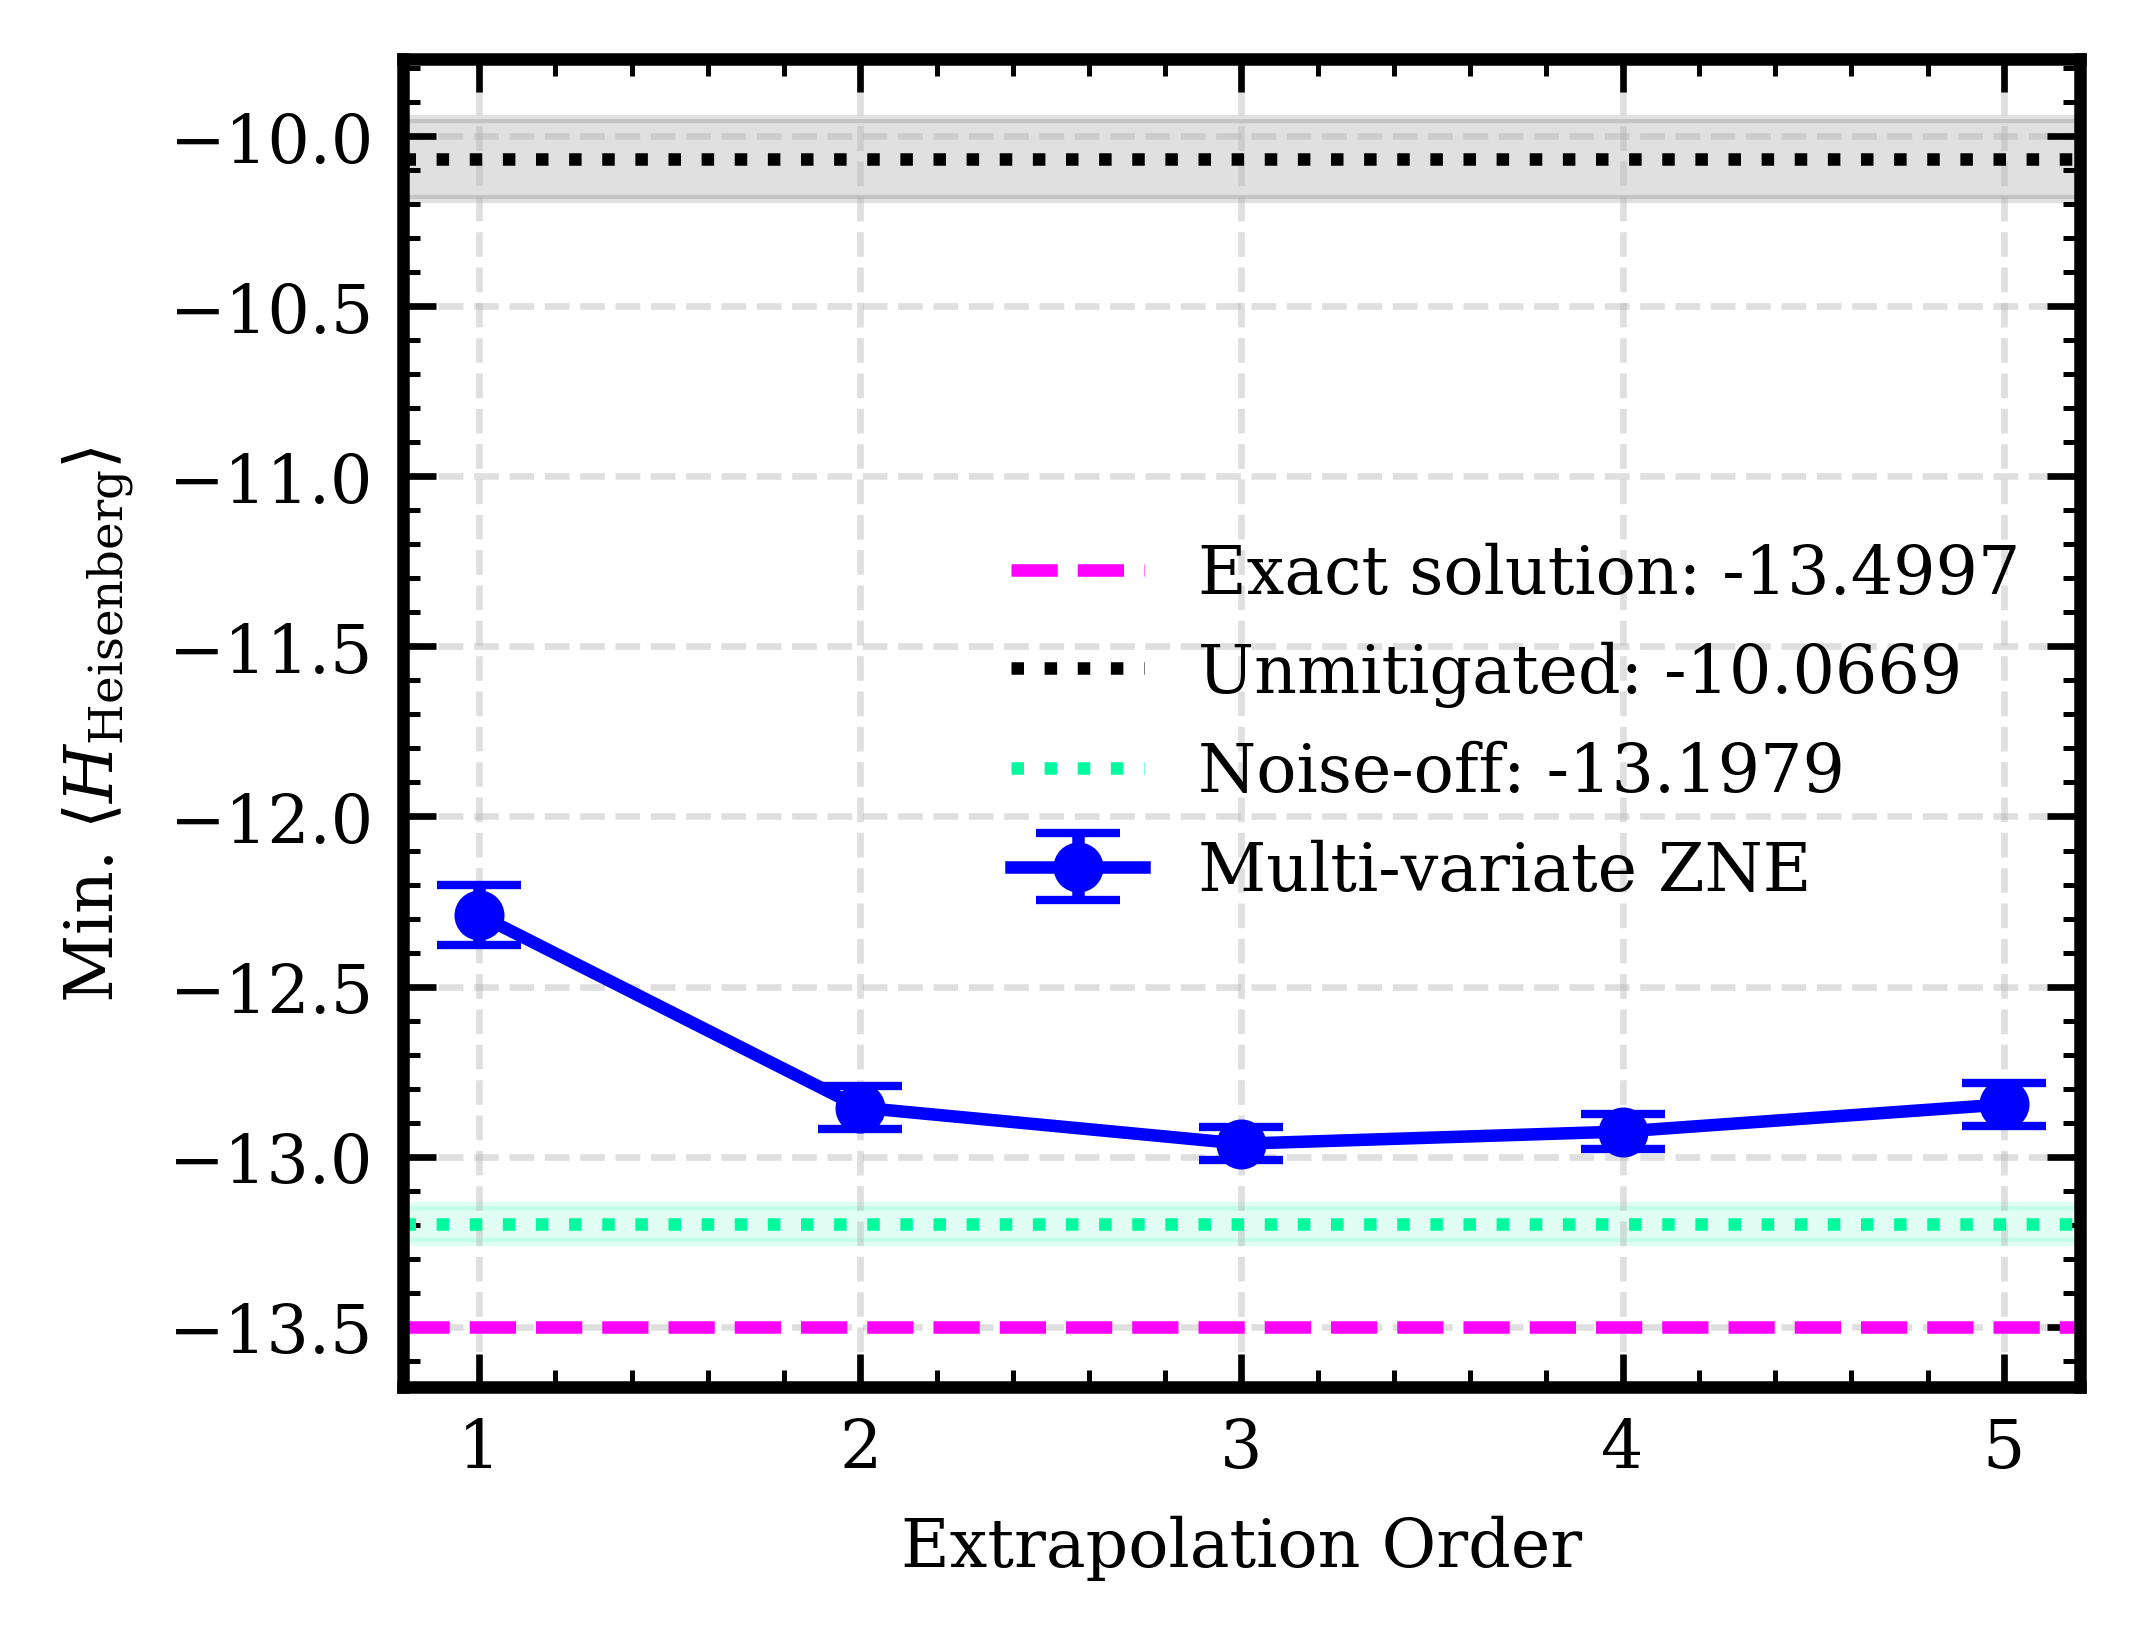

In [14]:
ricmul_plot_zne_vs_degree(
    processed_mul_var = PROCESSED_SIM_DATA["HEISENBERG_DEPH"]["ZNE-mul-var"],
    plot_colors       = {"zne": "#0000ff", "noisy": "black",
                      "exact": "magenta", "noise_off": "#00fb9f", "unmitigated": "black"},
    plot_file_name    = "RESULT-MULTIVARIATE-RIC-ZNE-VS-ORDER-IEEE",
    zne_label = "Multi-variate ZNE",
    output_dir        = OUTPUT_DIR,
    exact_sol         = EXACT_SOL_HEISENBERG,
    annotate_cost     = False,
    save_format       = "png",
    show_plot      = False,
    dpi                   = 600,
    figsize               = FIG_SIZE_IEEE_DOUBLE,
    tick_fontsize  = 8,
    label_fontsize = 8,
    capsize  = 5,
    marker_size  = 5,
    border_width  = 1.5,
    ylabel = r"Min. $\langle H_{\text{Heisenberg}} \rangle$"
)

Single-variate

In [15]:
# fig = ric_plot_zne_vs_degree(
#     DATA=PROCESSED_SIM_DATA["HEISENBERG_DEPH"]["ZNE-single-var"],
#     plot_colors       = {"zne": "#0000ff", "noisy": "black",
#                       "exact": "magenta", "noise_off": "#00fb9f", "unmitigated": "black"},
#     plot_file_name="RESULT-SINGLE-RIC-ZNE-VS-ORDER-ALL-GATES-NOISY-IEEE",
#     output_dir=OUTPUT_DIR,
#     save_format="png",
#     show_plot=True,
#     annotate_values = False,
#     dpi                   = 600,
#     figsize               = FIG_SIZE_IEEE_DOUBLE,
#     marker_size           = 5,
#     capsize               = 5, 
#     ylabel = r"Min. $\langle H_{\text{Ising}} \rangle$"

# )

## ZNE Table

### Degree 1

Saved EPS -> reports/8Q-t20-dephasing-target-heisenberg_zne-table-mul-var.eps  |  width=3.5000 in  dpi=600
Saved PNG -> reports/8Q-t20-dephasing-target-heisenberg_zne-table-mul-var.png  |  2100x648 px  (3.5000 x 1.0800 in at 600 dpi)

--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-13.198 \pm 0.052 $\\
        \hline
        At base noise $= [4, 1, 1]$ & $-10.067 \pm 0.116 $\\
        At boosted noise $= [36, 3, 3]$ & $-4.284 \pm 0.191 $\\
        At boosted noise $= [52, 3, 3]$ & $-3.393 \pm 0.191 $\\
        At boosted noise $= [60, 3, 5]$ & $-2.592 \pm 0.171 $\\
        \hline
        \text{Multi-variate Richardson ZNE value} & $-12.289 \pm 0.087$ \\
        \hline
------------------------



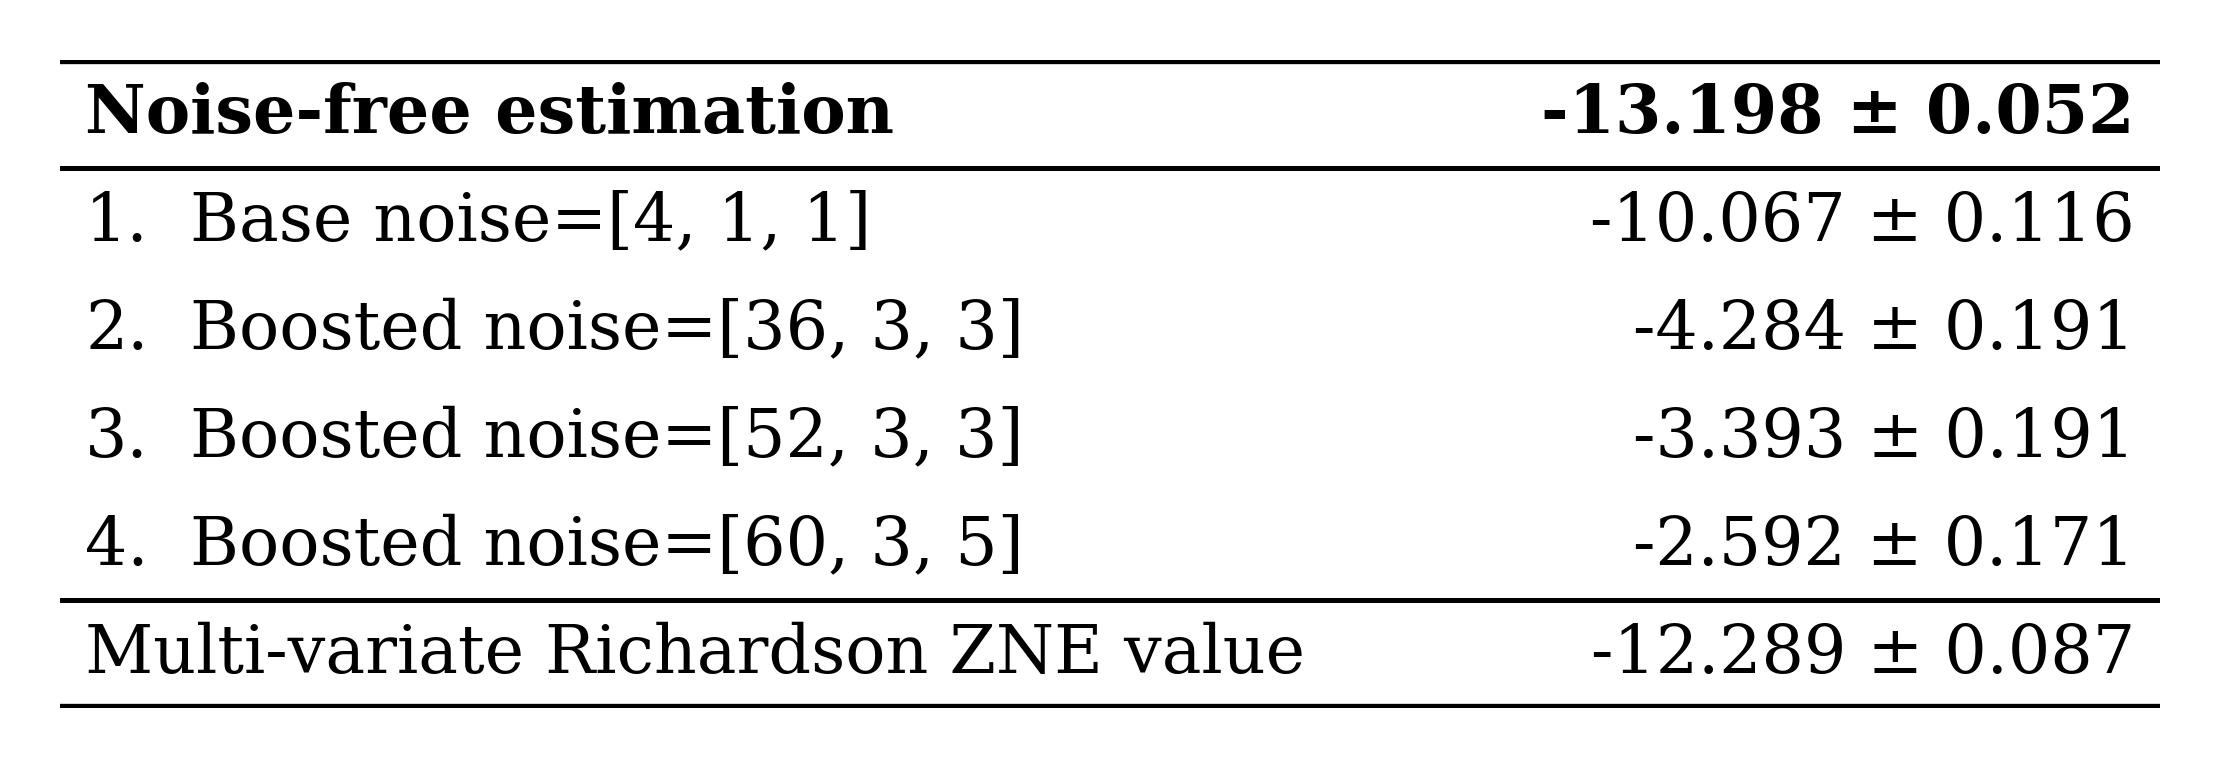

In [16]:
make_multivatiate_zne_table(PROCESSED_SIM_DATA["HEISENBERG_DEPH"]["ZNE-mul-var"]["muld1"], output_dir=OUTPUT_DIR, filename_stem=f"{_SYSTEM_HEISENEBRG}_zne-table-mul-var", fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

### Degree 2

Saved EPS -> reports/8Q-t20-dephasing-target-heisenberg_zne-table-mul-var.eps  |  width=3.5000 in  dpi=600
Saved PNG -> reports/8Q-t20-dephasing-target-heisenberg_zne-table-mul-var.png  |  2100x1296 px  (3.5000 x 2.1600 in at 600 dpi)

--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-13.198 \pm 0.052 $\\
        \hline
        At base noise $= [4, 1, 1]$ & $-10.067 \pm 0.116 $\\
        At boosted noise $= [36, 3, 3]$ & $-4.284 \pm 0.191 $\\
        At boosted noise $= [36, 5, 3]$ & $-3.477 \pm 0.196 $\\
        At boosted noise $= [52, 3, 3]$ & $-3.393 \pm 0.191 $\\
        At boosted noise $= [52, 5, 3]$ & $-2.761 \pm 0.186 $\\
        At boosted noise $= [60, 3, 5]$ & $-2.592 \pm 0.171 $\\
        At boosted noise $= [60, 5, 5]$ & $-2.114 \pm 0.163 $\\
        At boosted noise $= [68, 3, 3]$ & $-2.705 \pm 0.187 $\\
        At boosted noise $= [84, 3, 7]$ & $-1.612 \pm 0.147 $\\
        At boosted noise $= [92, 3, 5]$ & $-1.680 \pm 0.157 $\\
        \hline
        \t

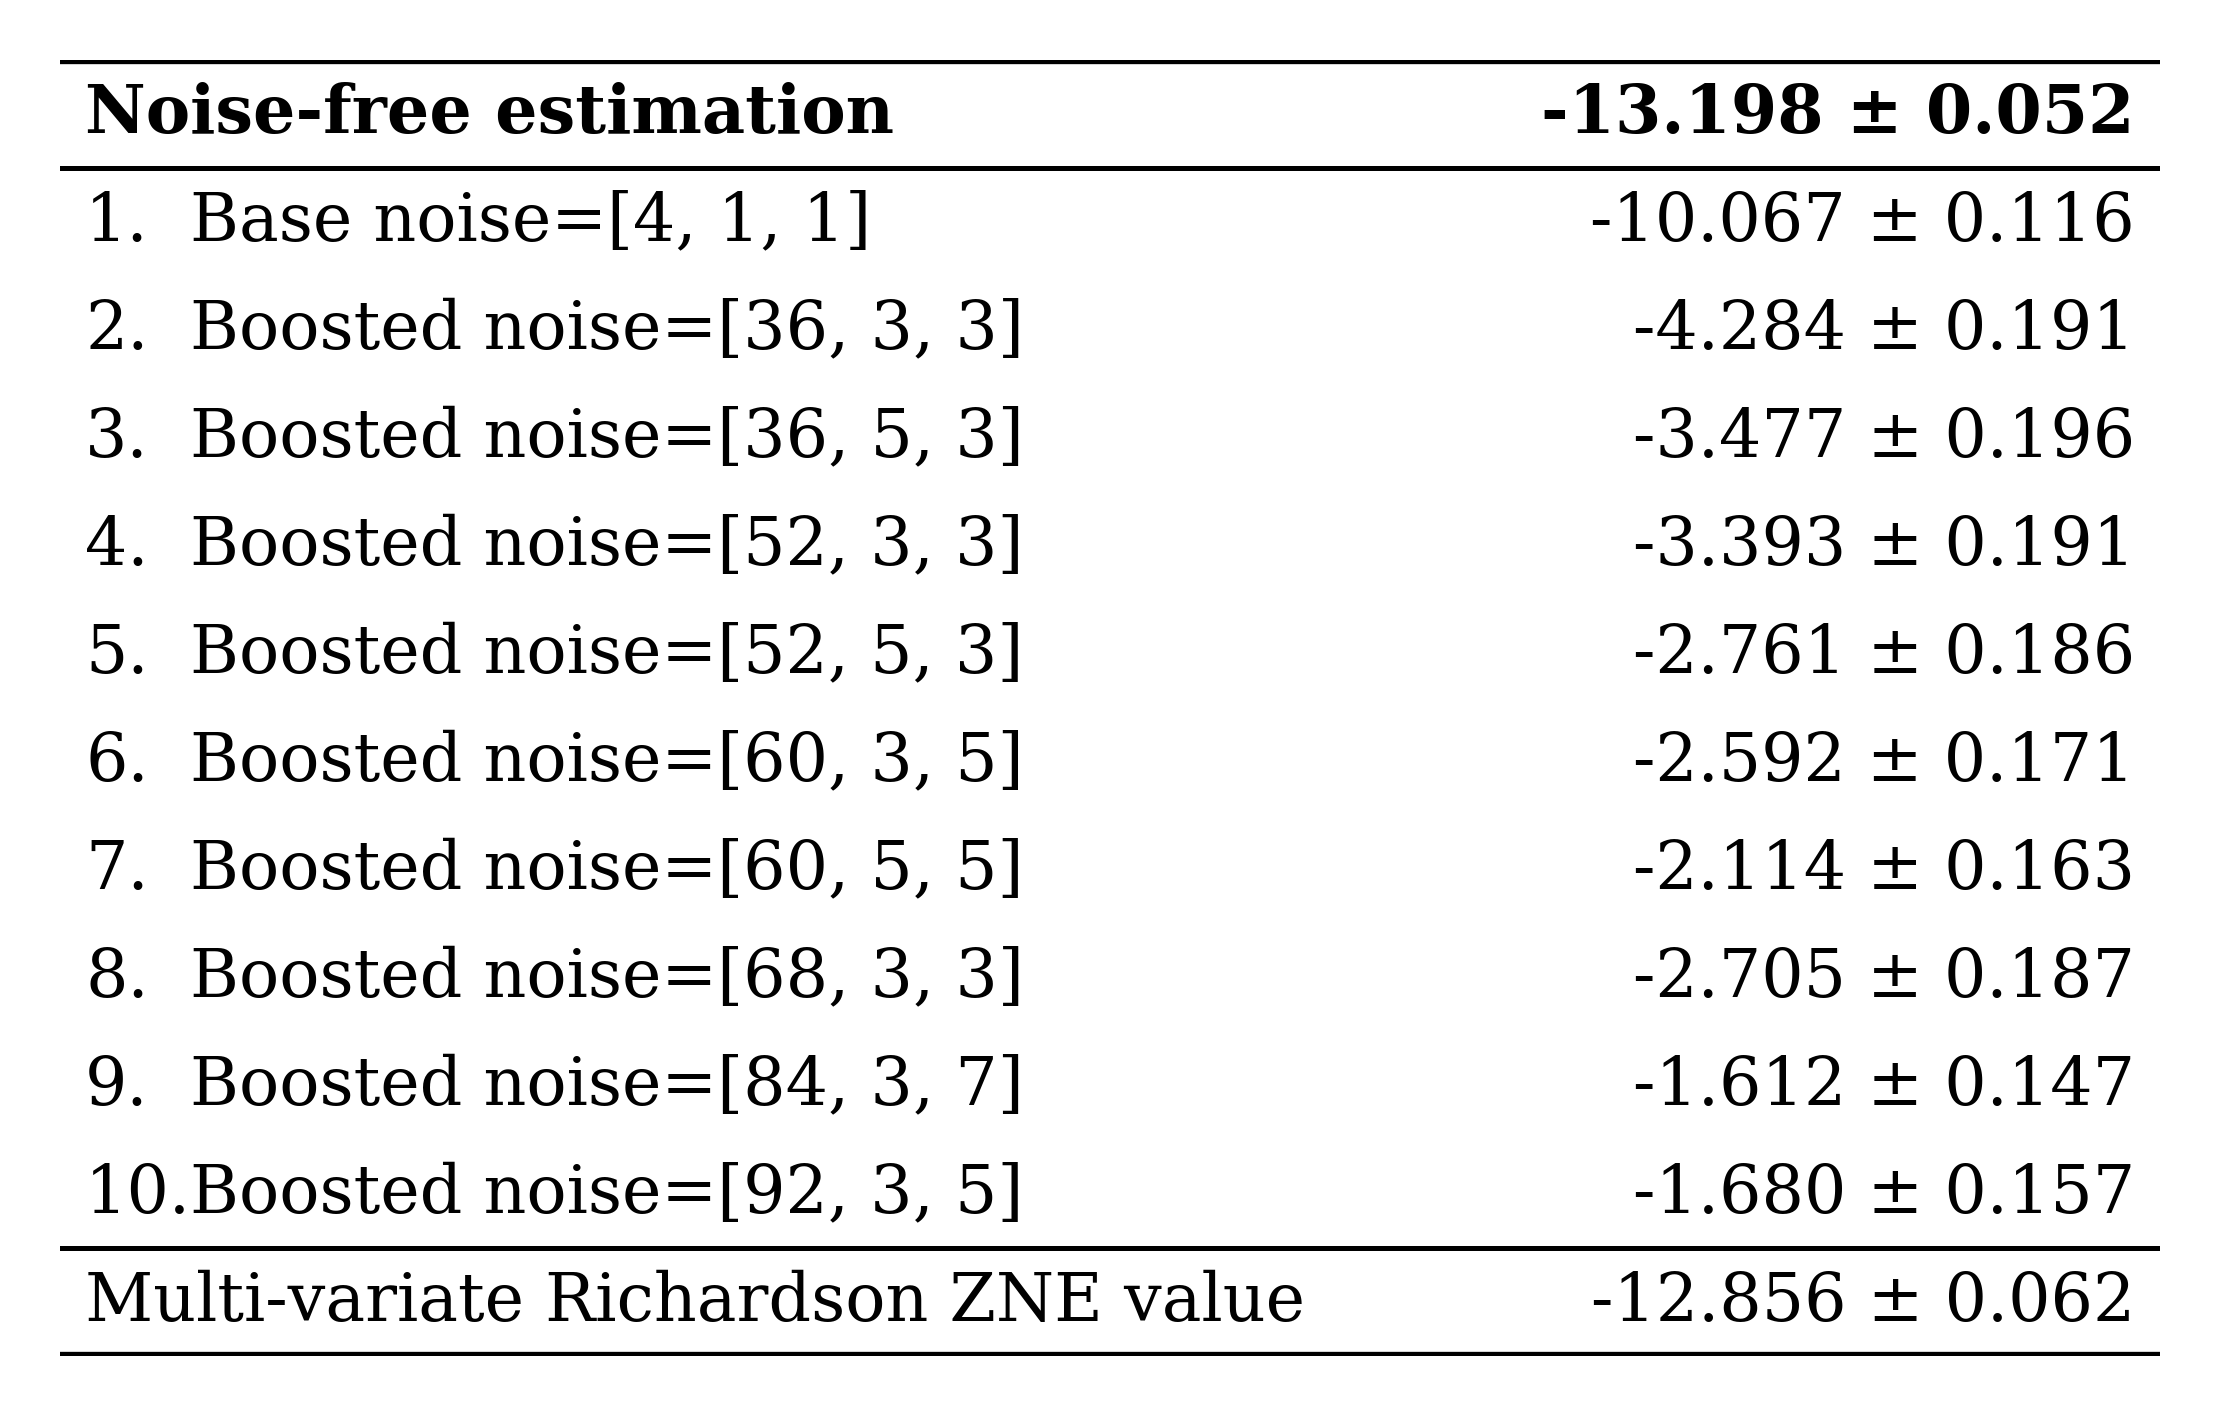

In [17]:
make_multivatiate_zne_table(PROCESSED_SIM_DATA["HEISENBERG_DEPH"]["ZNE-mul-var"]["muld2"], output_dir=OUTPUT_DIR, filename_stem=f"{_SYSTEM_HEISENEBRG}_zne-table-mul-var", fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

### Degree 3

Saved EPS -> reports/8Q-t20-dephasing-target-heisenberg_zne-table-mul-var.eps  |  width=3.5000 in  dpi=600
Saved PNG -> reports/8Q-t20-dephasing-target-heisenberg_zne-table-mul-var.png  |  2100x2376 px  (3.5000 x 3.9600 in at 600 dpi)

--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-13.198 \pm 0.052 $\\
        \hline
        At base noise $= [4, 1, 1]$ & $-10.067 \pm 0.116 $\\
        At boosted noise $= [36, 3, 3]$ & $-4.284 \pm 0.191 $\\
        At boosted noise $= [36, 5, 3]$ & $-3.477 \pm 0.196 $\\
        At boosted noise $= [36, 7, 3]$ & $-2.844 \pm 0.196 $\\
        At boosted noise $= [52, 3, 3]$ & $-3.393 \pm 0.191 $\\
        At boosted noise $= [52, 5, 3]$ & $-2.761 \pm 0.186 $\\
        At boosted noise $= [52, 7, 3]$ & $-2.263 \pm 0.180 $\\
        At boosted noise $= [60, 3, 5]$ & $-2.592 \pm 0.171 $\\
        At boosted noise $= [60, 5, 5]$ & $-2.114 \pm 0.163 $\\
        At boosted noise $= [60, 7, 5]$ & $-1.735 \pm 0.155 $\\
        At boosted noise 

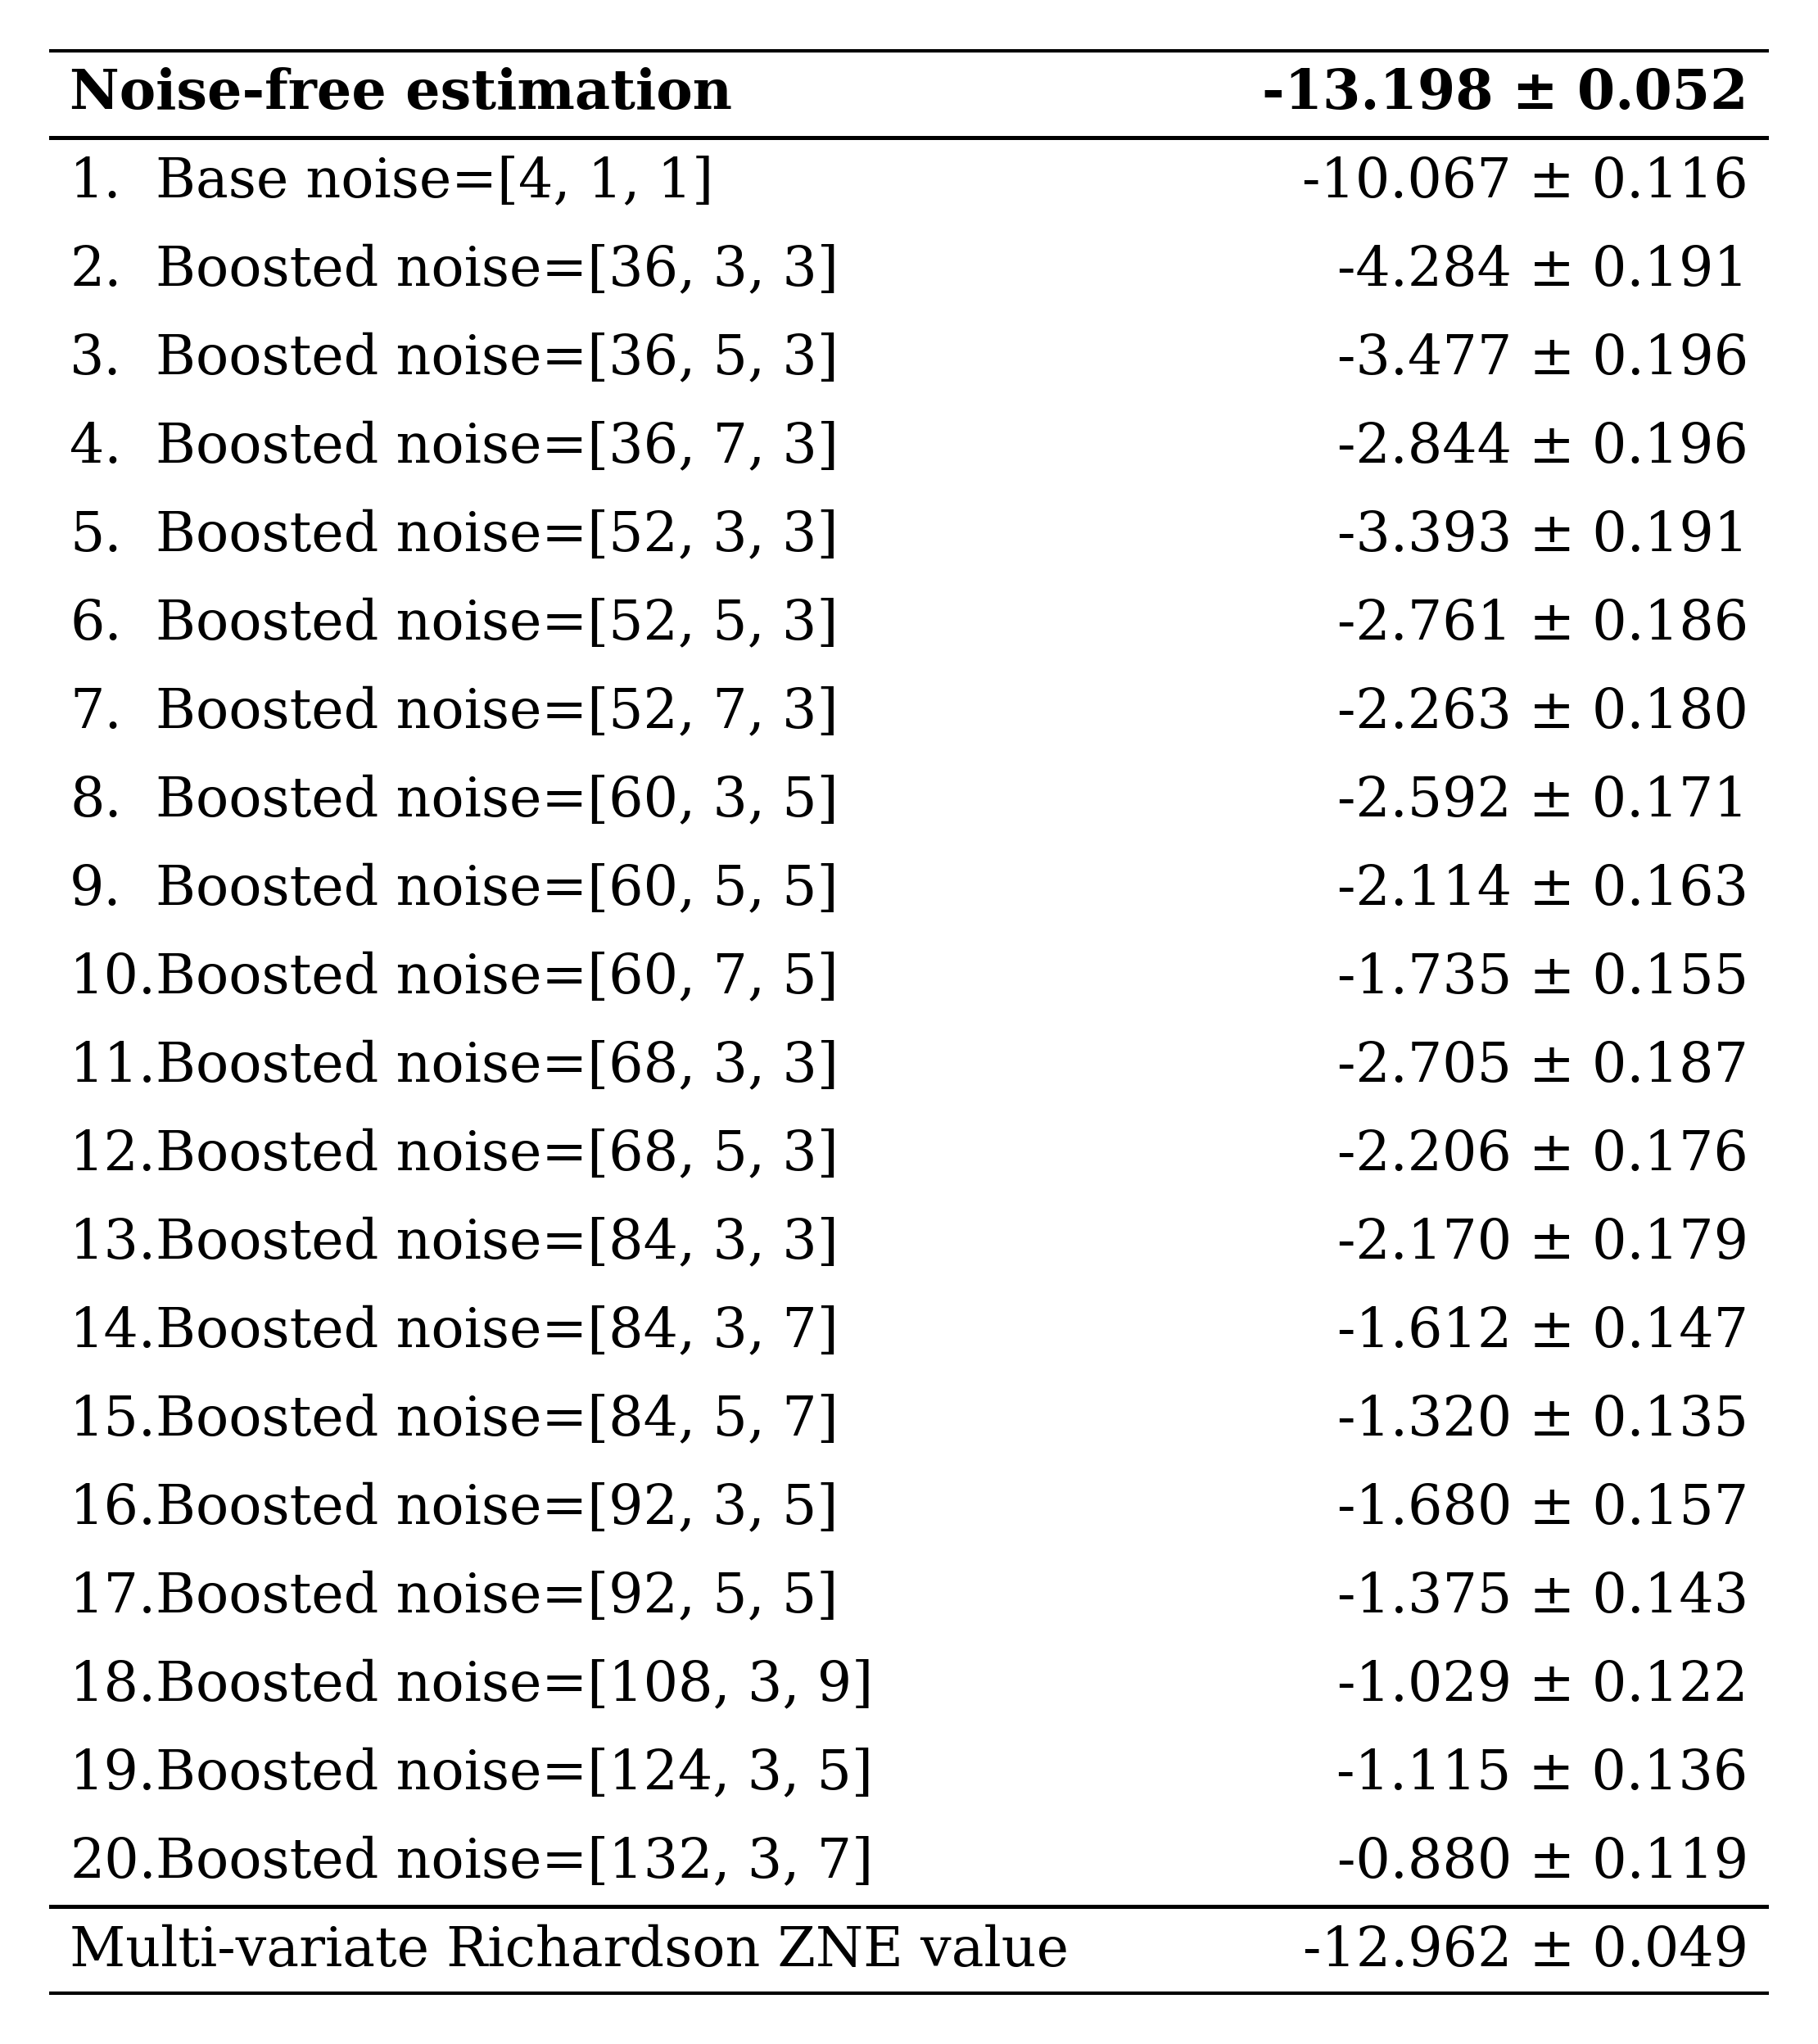

In [18]:
make_multivatiate_zne_table(PROCESSED_SIM_DATA["HEISENBERG_DEPH"]["ZNE-mul-var"]["muld3"], output_dir=OUTPUT_DIR, filename_stem=f"{_SYSTEM_HEISENEBRG}_zne-table-mul-var", fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

### Degree 4

Saved EPS -> reports/8Q-t20-dephasing-target-heisenberg_zne-table-mul-var.eps  |  width=3.5000 in  dpi=600
Saved PNG -> reports/8Q-t20-dephasing-target-heisenberg_zne-table-mul-var.png  |  2100x3996 px  (3.5000 x 6.6600 in at 600 dpi)

--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-13.198 \pm 0.052 $\\
        \hline
        At base noise $= [4, 1, 1]$ & $-10.067 \pm 0.116 $\\
        At boosted noise $= [36, 3, 3]$ & $-4.284 \pm 0.191 $\\
        At boosted noise $= [36, 5, 3]$ & $-3.477 \pm 0.196 $\\
        At boosted noise $= [36, 7, 3]$ & $-2.844 \pm 0.196 $\\
        At boosted noise $= [36, 9, 3]$ & $-2.342 \pm 0.192 $\\
        At boosted noise $= [52, 3, 3]$ & $-3.393 \pm 0.191 $\\
        At boosted noise $= [52, 5, 3]$ & $-2.761 \pm 0.186 $\\
        At boosted noise $= [52, 7, 3]$ & $-2.263 \pm 0.180 $\\
        At boosted noise $= [52, 9, 3]$ & $-1.865 \pm 0.173 $\\
        At boosted noise $= [60, 3, 5]$ & $-2.592 \pm 0.171 $\\
        At boosted noise 

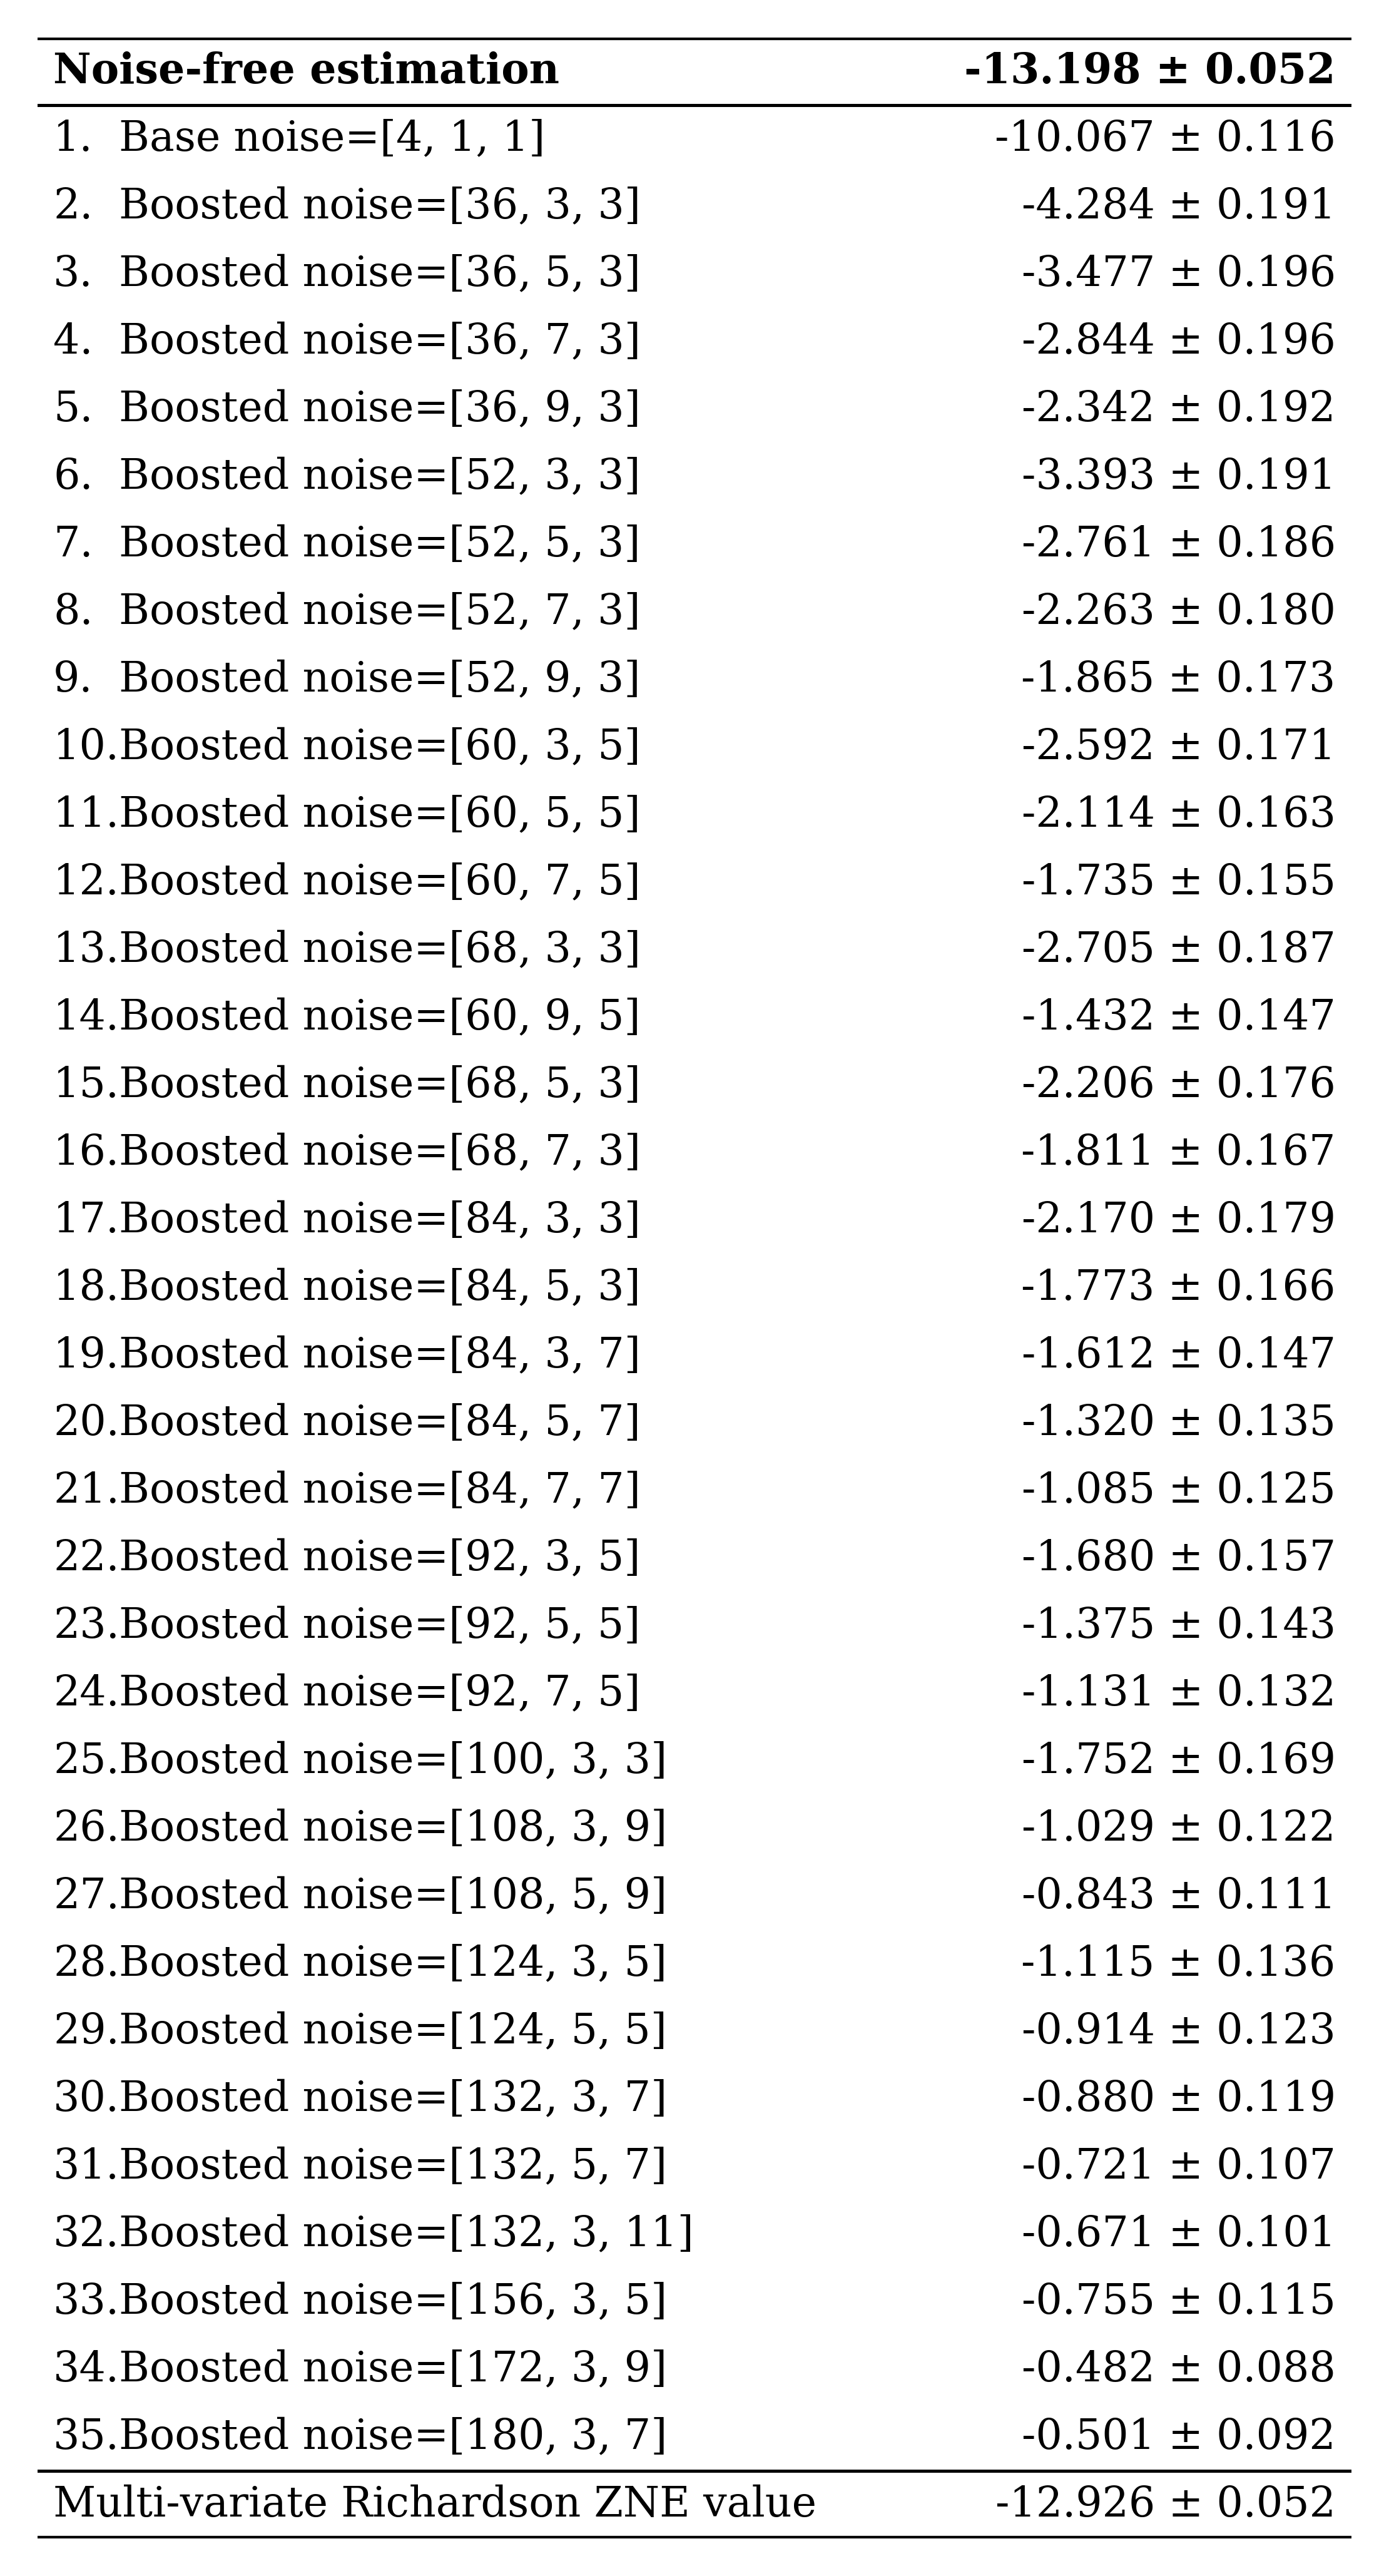

In [19]:
make_multivatiate_zne_table(PROCESSED_SIM_DATA["HEISENBERG_DEPH"]["ZNE-mul-var"]["muld4"], output_dir=OUTPUT_DIR, filename_stem=f"{_SYSTEM_HEISENEBRG}_zne-table-mul-var", fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

### Degree 5

Saved EPS -> reports/8Q-t20-dephasing-target-heisenberg_zne-table-mul-var.eps  |  width=3.5000 in  dpi=600
Saved PNG -> reports/8Q-t20-dephasing-target-heisenberg_zne-table-mul-var.png  |  2100x6264 px  (3.5000 x 10.4400 in at 600 dpi)

--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-13.198 \pm 0.052 $\\
        \hline
        At base noise $= [4, 1, 1]$ & $-10.067 \pm 0.116 $\\
        At boosted noise $= [36, 3, 3]$ & $-4.284 \pm 0.191 $\\
        At boosted noise $= [36, 5, 3]$ & $-3.477 \pm 0.196 $\\
        At boosted noise $= [36, 7, 3]$ & $-2.844 \pm 0.196 $\\
        At boosted noise $= [36, 9, 3]$ & $-2.342 \pm 0.192 $\\
        At boosted noise $= [36, 11, 3]$ & $-1.939 \pm 0.187 $\\
        At boosted noise $= [52, 3, 3]$ & $-3.393 \pm 0.191 $\\
        At boosted noise $= [52, 5, 3]$ & $-2.761 \pm 0.186 $\\
        At boosted noise $= [52, 7, 3]$ & $-2.263 \pm 0.180 $\\
        At boosted noise $= [52, 9, 3]$ & $-1.865 \pm 0.173 $\\
        At boosted nois

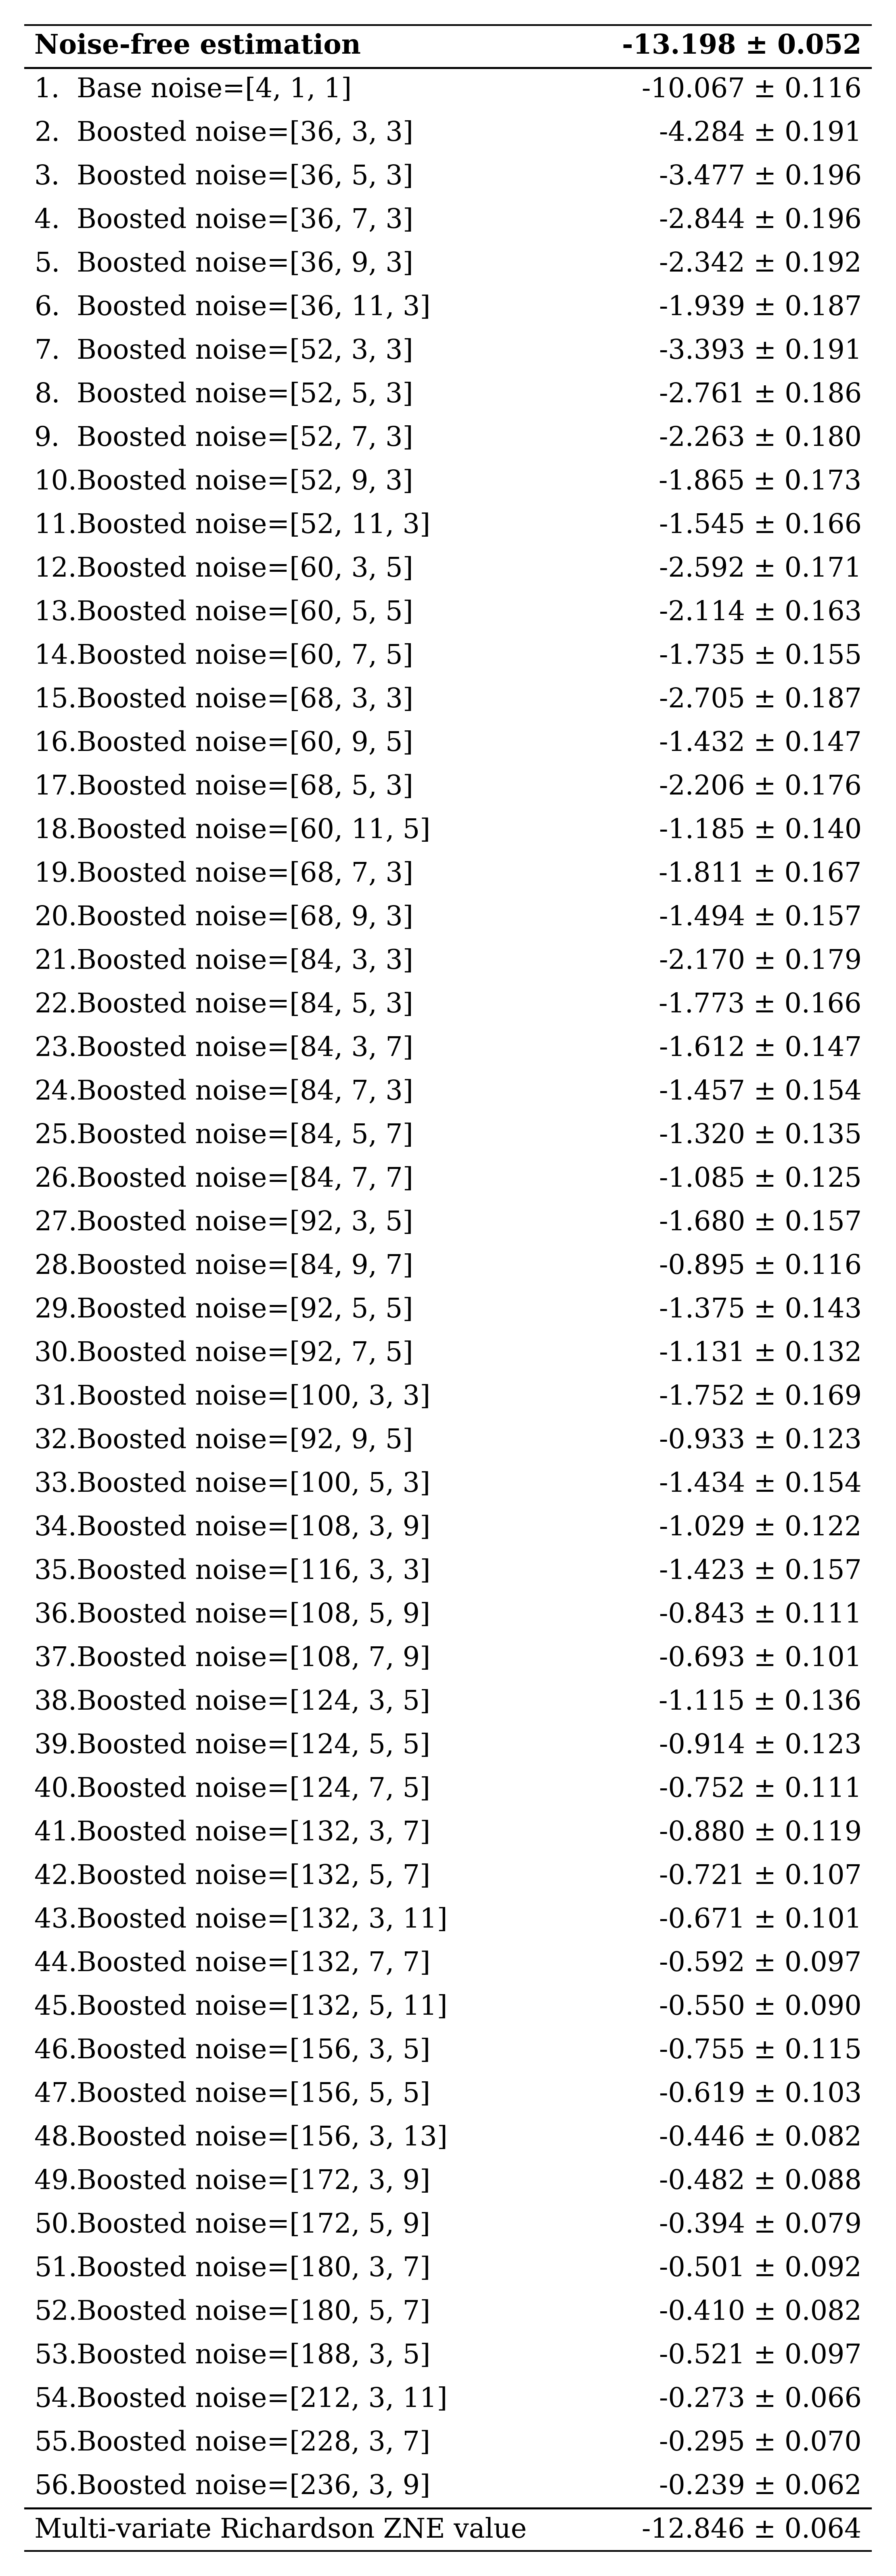

In [20]:
make_multivatiate_zne_table(PROCESSED_SIM_DATA["HEISENBERG_DEPH"]["ZNE-mul-var"]["muld5"], output_dir=OUTPUT_DIR, filename_stem=f"{_SYSTEM_HEISENEBRG}_zne-table-mul-var", fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

---

# ✅ Additional Analysis

## Sampling Overhead



### Multi-variate ZNE

The sampling overhead $c$ is defined as the ratio of total shots required with error mitigation to those required without:

$$c := \frac{s_\text{tot}}{s_\text{u}}$$

#### Optimal shot allocation (multi-variate case)

For a fixed total shot budget $s_\text{tot}$, allocating shots proportionally to $s_i \propto |\eta_i|$ minimizes overhead. The sampling overhead is then ([Quantum error mitigation by layerwise Richardson extrapolation](https://arxiv.org/abs/2402.04000)):

$$c := \frac{s_\text{tot}}{s_\text{u}} = \gamma^2, \qquad \gamma := \sum_{i=1}^{M} |\eta_i|, \qquad s_i = \frac{s_\text{tot}\,|\eta_i|}{\gamma}$$

where $M$ is the number of noise-scaled circuits, $\eta_i$ are the extrapolation coefficients, and $s_i$ is the number of shots allocated to the $i$-th circuit.

#### Equal shot allocation (multi-variate case)

If instead all $M$ circuits are measured with equal shots $s_i = s_\text{tot}/M$, the overhead increases to:

$$\tilde{c} := \frac{s_\text{tot}}{s_\text{u}} = M\tilde{\gamma}^2, \qquad \tilde{\gamma} := \left(\sum_{i=1}^{M} |\eta_i|^2\right)^{1/2}$$

Note that $\tilde{c} \geq c$ always, so optimal allocation is preferred when $|\eta_i|$ vary significantly across circuits.

### Single-variate Richardson extrapolation

For standard (univariate) Richardson extrapolation with polynomial order $n$, the sampling overhead is ([Hybrid quantum-classical algorithms and quantum error mitigation](https://arxiv.org/abs/2011.01382)):

$$\gamma_\text{Ric} := \sum_{k=0}^{n} \beta_k^2$$

where $\beta_k$ are the Richardson extrapolation coefficients and $\gamma_\text{Ric}$ is the factor by which the variance increases relative to the unmitigated case — i.e. $\gamma_\text{Ric}$ times more samples are needed to match the unmitigated shot noise.


> 💡 **Note:** The sampling overhead cost $c$ (and thus $\gamma$) depends solely on the
> extrapolation coefficients $\beta_k$ (single-variate) or $\eta_i$ (multivariate),
> which are fully determined by the noise scaling levels and extrapolation order —
> not on the measurement outcomes. Therefore, the cost is identical across all trials
> for a given order, and its standard deviation is exactly zero (up to floating-point
> rounding errors on the order of $\sim 10^{-14}$–$10^{-12}$).

## 🌟 Plot: Multi-Variate ZNE Cost Overhead

Order  2 | Mean      = 165.765625 | Std       = 0.000000 | Bar Mean  = 351.381836 | Bar Std   = 0.000000
Order  1 | Mean      = 12.250000 | Std       = 0.000000 | Bar Mean  = 17.500000 | Bar Std   = 0.000000
Order  5 | Mean      = 98482.745440 | Std       = 0.000000 | Bar Mean  = 315496.108005 | Bar Std   = 0.000000
Order  3 | Mean      = 1614.407288 | Std       = 0.000000 | Bar Mean  = 4348.969913 | Bar Std   = 0.000000
Order  4 | Mean      = 12941.062089 | Std       = 0.000000 | Bar Mean  = 38714.738740 | Bar Std   = 0.000000


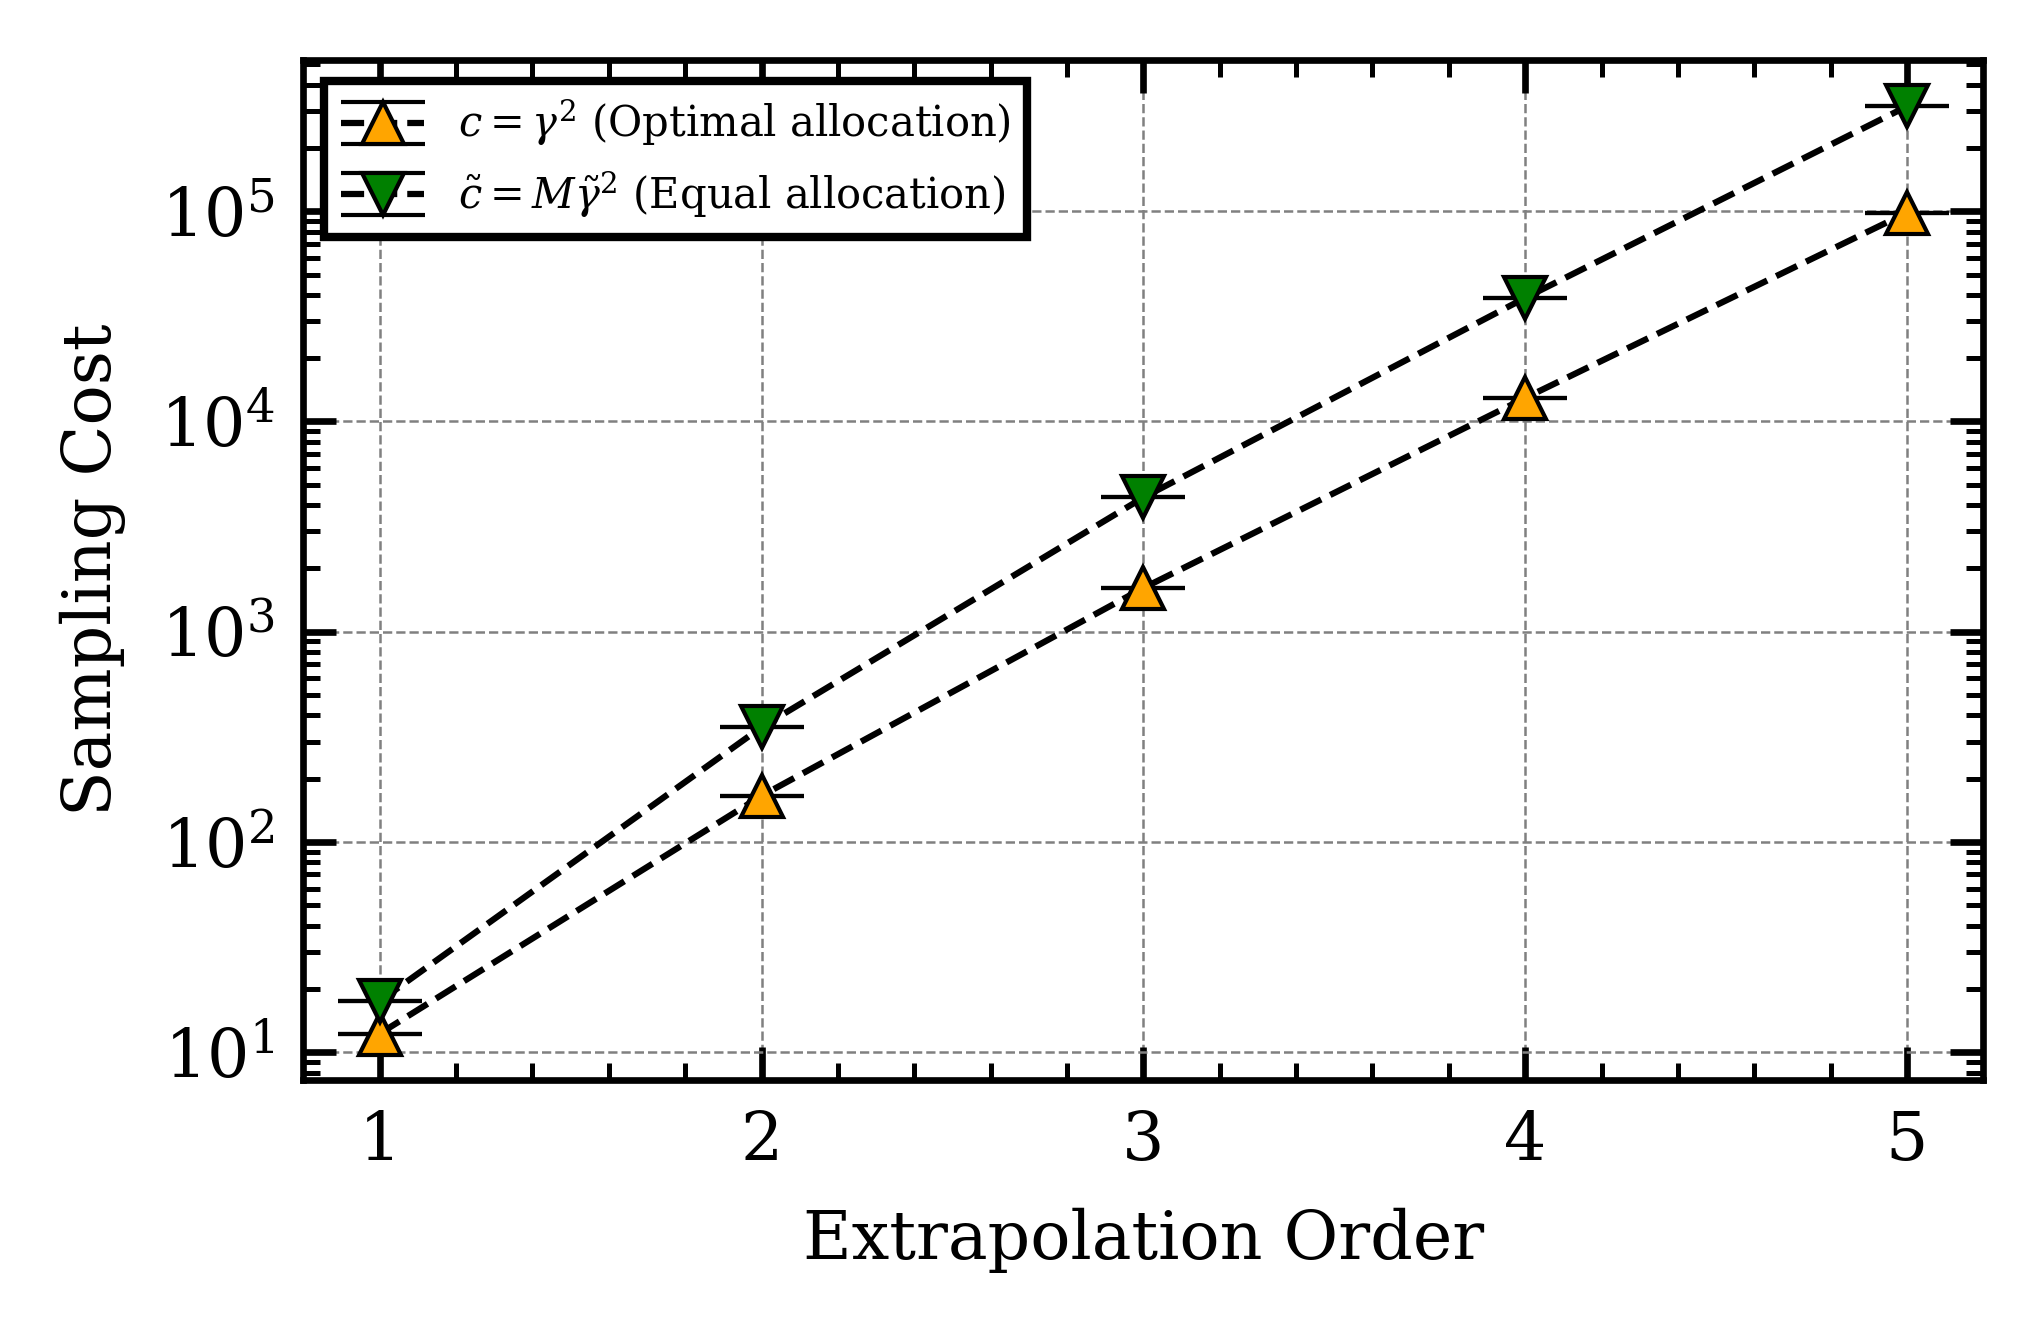

In [21]:
zne_cost_overhead = []
zne_cost_std = []
zne_order = []
zne_cost_bar_overhead = []
zne_cost_bar_std = []
zne_overhead_stats = {}
_target = PROCESSED_SIM_DATA["HEISENBERG_DEPH"]["ZNE-mul-var"]

# 1. Extract data
for item in _target:
    order = _target[item]["order"]
    zne_cost_overhead.append(_target[item]["cost_mean"])
    zne_cost_std.append(_target[item]["cost_std"])
    zne_order.append(_target[item]["order"])
    zne_cost_bar_overhead.append(_target[item]["cost_bar_mean"])
    zne_cost_bar_std.append(_target[item]["cost_bar_std"])
    print(
        f"Order {_target[item]['order']:>2} | "
        f"Mean      = {_target[item]['cost_mean']:.6f} | "
        f"Std       = {_target[item]['cost_std']:.6f} | "
        f"Bar Mean  = {_target[item]['cost_bar_mean']:.6f} | "
        f"Bar Std   = {_target[item]['cost_bar_std']:.6f}"
    )
    zne_overhead_stats[order] = {
        "cost": _target[item]["cost_mean"],
        "cost_std": _target[item]["cost_std"],
        "cost_bar": _target[item]["cost_bar_mean"],
        "cost_bar_std": _target[item]["cost_bar_std"],
    }

# 2. Sort all arrays together to keep everything synchronized
sorted_data = sorted(zip(zne_order, zne_cost_overhead, zne_cost_std,
                         zne_cost_bar_overhead, zne_cost_bar_std))
zne_order, zne_cost_overhead, zne_cost_std, \
zne_cost_bar_overhead, zne_cost_bar_std = zip(*sorted_data)

# 3. Plot
plt.figure(figsize=(3.5, 2.5))

plt.errorbar(
    zne_order, zne_cost_overhead, yerr=zne_cost_std,
    fmt='^', linestyle='--', color='black',
    linewidth=0.75, capsize=5, markersize=5,
    markerfacecolor='orange', markeredgecolor='black', markeredgewidth=0.5,
    label=r'$c = \gamma^2$ (Optimal allocation)'
)
plt.errorbar(
    zne_order, zne_cost_bar_overhead, yerr=zne_cost_bar_std,
    fmt='v', linestyle='--', color='black',
    linewidth=0.75, capsize=5, markersize=5,
    markerfacecolor='green', markeredgecolor='black', markeredgewidth=0.5,
    label=r'$\tilde{c} = M\tilde{\gamma}^2$ (Equal allocation)'
)


plt.yscale('log')
plt.xlabel('Extrapolation Order', fontsize=8)
plt.ylabel(r'Sampling Cost', fontsize=8)
plt.legend(
    fontsize=5, loc='upper left',
    framealpha=1.0, edgecolor='black', fancybox=False
)
plt.grid(True, color='grey', linestyle='--', linewidth=0.3)
plt.subplots_adjust(left=0.18, right=0.98, top=0.88, bottom=0.20)

os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR, f"REVIEW--{_SYSTEM_HEISENEBRG}_overhead_multivariate.eps"), format="eps", dpi=600)
plt.show()
plt.close()

In [22]:
print(zne_overhead_stats)

{2: {'cost': 165.76562499999915, 'cost_std': 2.842170943040401e-14, 'cost_bar': 351.38183593749824, 'cost_bar_std': 0.0}, 1: {'cost': 12.25, 'cost_std': 0.0, 'cost_bar': 17.5, 'cost_bar_std': 0.0}, 5: {'cost': 98482.74544026295, 'cost_std': 0.0, 'cost_bar': 315496.1080048842, 'cost_bar_std': 0.0}, 3: {'cost': 1614.4072875976015, 'cost_std': 0.0, 'cost_bar': 4348.969913058701, 'cost_bar_std': 9.094947017729282e-13}, 4: {'cost': 12941.062088941126, 'cost_std': 1.8189894035458565e-12, 'cost_bar': 38714.73874038836, 'cost_bar_std': 0.0}}


---

## Circuit-dpeth Overhead

In [23]:
def load_redundant_gate_counts(filepath: str) -> dict:
    """
    Loads a _REDUNDANT.json file and extracts raw_gate_count for each
    noise detail entry.

    Returns
    -------
    dict with keys:
        "filepath"        : str  — source file path
        "raw_gate_counts" : list of dicts, one per noise_details entry,
                            each containing "identity_factors" and "raw_gate_count"
    """
    with open(filepath, "r") as f:
        data = json.load(f)

    noise_details = data["output"]["noise_details"]

    raw_gate_counts = [
        {
            "identity_factors": entry["identity_factors"],
            "raw_gate_count":   entry["raw_gate_count"],
        }
        for entry in noise_details
    ]

    return {
        "filepath":        filepath,
        "raw_gate_counts": raw_gate_counts,
    }

def load_all_redundant_gate_counts(folder: str) -> dict:
    """
    Scans each muldN subfolder under folder, reads the first _REDUNDANT.json
    found, and extracts its raw_gate_counts (all entries in a muld are identical).

    Returns
    -------
    dict keyed by subfolder name, e.g.:
        {
            "muld1": [
                {"identity_factors": [0,0,0,0], "raw_gate_count": {...}},
                ...
            ],
            "muld2": [...],
        }
    """
    results = {}
    for subfolder in sorted(os.listdir(folder)):
        subfolder_path = os.path.join(folder, subfolder)
        if not os.path.isdir(subfolder_path):
            continue
        for fname in sorted(os.listdir(subfolder_path)):
            if fname.endswith("_REDUNDANT.json"):
                fpath = os.path.join(subfolder_path, fname)
                entry = load_redundant_gate_counts(fpath)
                results[subfolder] = entry["raw_gate_counts"]
                break  # one file is enough

    return results

In [24]:
GATE_COUNTS = load_all_redundant_gate_counts(
    os.path.join(BASE_DIR, f"{_SYSTEM_ISING}/ZNE", "ZNE-mul-var")
)

In [25]:
print(GATE_COUNTS["muld1"])

[{'identity_factors': [0, 0, 0, 0], 'raw_gate_count': {'R': 4, 'CZ': 1, 'U': 1, 'Y': 0, 'total': 6}}, {'identity_factors': [1, 1, 1, 1], 'raw_gate_count': {'R': 12, 'CZ': 3, 'U': 3, 'Y': 24, 'total': 42}}, {'identity_factors': [1, 1, 1, 2], 'raw_gate_count': {'R': 12, 'CZ': 3, 'U': 3, 'Y': 40, 'total': 58}}, {'identity_factors': [1, 1, 2, 1], 'raw_gate_count': {'R': 12, 'CZ': 3, 'U': 5, 'Y': 48, 'total': 68}}]


In [26]:
LAYERS: int = RAW_SIM_DATA["8Q-t20-dephasing-target-heisenberg"]["VQE"]["8Q-t20-dephasing-target-heisenberg_run000_VQE"]["config"]["ansatz"]["layer"]
print(f"Layers: {LAYERS}")

Layers: 30


In [27]:
ODD_SITES = 4
def compute_depth(raw_gate_counts: list, ODD_SITES: int = ODD_SITES) -> float:
    """
    Computes circuit depth for a given muld as:
        depth = sum over all identity_factors of (R/2 + CZ + U + Y/ODD_SITES)

    Parameters
    ----------
    raw_gate_counts : list of dicts (as returned by load_all_redundant_gate_counts)
        Each dict has 'identity_factors' and 'raw_gate_count'.

    Returns
    -------
    float : total depth
    """
    depth = 0.0
    for entry in raw_gate_counts:
        gc = entry["raw_gate_count"]
        depth += (gc["R"] / 2 + gc["CZ"] + gc["U"] + gc["Y"] / ODD_SITES ) *LAYERS
        print(f"Identity factors: {entry['identity_factors']} -> Depth contribution: {(gc['R'] / 2 + gc['CZ'] + gc['U'] + gc['Y'] / ODD_SITES ) *LAYERS}")
    print("****")
    print("Total depth:", depth)
    print("****\n\n")
    return depth

In [28]:
depths = {muld: compute_depth(counts) for muld, counts in GATE_COUNTS.items()}

Identity factors: [0, 0, 0, 0] -> Depth contribution: 120.0
Identity factors: [1, 1, 1, 1] -> Depth contribution: 540.0
Identity factors: [1, 1, 1, 2] -> Depth contribution: 660.0
Identity factors: [1, 1, 2, 1] -> Depth contribution: 780.0
****
Total depth: 2100.0
****


Identity factors: [0, 0, 0, 0] -> Depth contribution: 120.0
Identity factors: [1, 1, 1, 1] -> Depth contribution: 540.0
Identity factors: [1, 1, 1, 2] -> Depth contribution: 660.0
Identity factors: [1, 1, 1, 3] -> Depth contribution: 780.0
Identity factors: [1, 1, 2, 1] -> Depth contribution: 780.0
Identity factors: [1, 1, 2, 2] -> Depth contribution: 1020.0
Identity factors: [1, 1, 3, 1] -> Depth contribution: 1020.0
Identity factors: [1, 2, 1, 1] -> Depth contribution: 600.0
Identity factors: [1, 2, 1, 2] -> Depth contribution: 720.0
Identity factors: [1, 2, 2, 1] -> Depth contribution: 840.0
****
Total depth: 7080.0
****


Identity factors: [0, 0, 0, 0] -> Depth contribution: 120.0
Identity factors: [1, 1, 1, 1] -> 

In [29]:
depths

{'muld1': 2100.0,
 'muld2': 7080.0,
 'muld3': 17220.0,
 'muld4': 35460.0,
 'muld5': 65640.0}

### 🌟 Plot

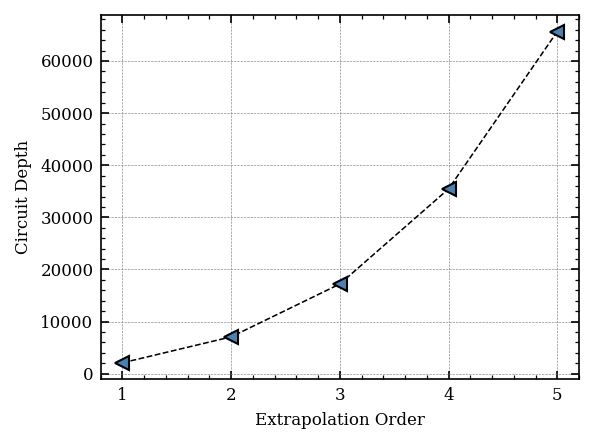

In [30]:
def plot_depth_vs_order(depths: dict, fig_width: float = 4.0, dpi: int = 150):
    """
    Plots circuit depth vs polynomial order.
    muldN maps to order N (muld1 → order 1, muld2 → order 2, ...).
    """
    orders = []
    depth_vals = []

    for muld, depth in sorted(depths.items(), key=lambda x: int(x[0].replace("muld", ""))):
        order = int(muld.replace("muld", ""))
        orders.append(order)
        depth_vals.append(depth)

    fig, ax = plt.subplots(figsize=(fig_width, fig_width * 0.75), dpi=dpi)

    ax.plot(
        orders,
        depth_vals,
        marker="<",
        linewidth=0.75,
        markersize=7,
        color="black",
        linestyle="--",
        markerfacecolor="steelblue",
        markeredgecolor="black",
        markeredgewidth=1.0
        )

    ax.set_xlabel("Extrapolation Order", fontsize=8)
    ax.set_ylabel("Circuit Depth")
    ax.set_xticks(orders)
    ax.grid(True, color='grey', linestyle='--', linewidth=0.3)
    #ax.set_yscale("log")
    fig.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "REVIEW--all-gates-noisy-multivar-depth_vs_order.png"), format="png", dpi=dpi)
    plt.show()
    return fig

fig = plot_depth_vs_order(depths)


---

## Runtime and Computational Cost

"runtime scaling" and "computational cost" may be the same for standard quantum circuits.
However, they are different for our problem setting.
This is because we are assuming that single qubits operations and CNOT operations can be applied immediately.

`"runtime"  = final T_max" × "number of measurement" × "number of shots"`

On the other hands, 

`computational cost (or computational complexity) = "number of gates" × "number of measurement" × "number of shots"`

This is for a single quantum circuit.
We need to sum up these values for all quantum circuits in a given algorithm when we calculate "run time" and " computational cost " for the whole algorithm.

That is, to calculate "runtime" and "computational cost" of VQE, we must sum up for all quantum circuits used in the optimization.

### Runtime overhead

In [31]:
TARGET =  RAW_SIM_DATA["8Q-t20-dephasing-target-heisenberg"]["ZNE"]["ZNE-mul-var"]
#CONSTANTS
COST_CALLING_VQE_0 :int = RAW_SIM_DATA["8Q-t20-dephasing-target-heisenberg"]["VQE"]["8Q-t20-dephasing-target-heisenberg_run000_VQE"]["others"]["cost_callings"]
FINAL_T_MAX: float = RAW_SIM_DATA["8Q-t20-dephasing-target-heisenberg"]["VQE"]["8Q-t20-dephasing-target-heisenberg_run000_VQE"]["output"]["optimized_parameters"][0][29]
################
degree_list = []
runtime_list = []
for item in TARGET:
    target_key = next(
        k for k in TARGET[item].keys()
        if "sample#1" in k and k.endswith("ZNE")
    )
    degree :int = TARGET[item][target_key]["output"]["zne_values"]["degree"]
    sampling_cost_for_a_degree = zne_overhead_stats[degree]["cost"]
    runtime_per_degree: float = FINAL_T_MAX * (sampling_cost_for_a_degree * COST_CALLING_VQE_0)
    degree_list.append(degree)
    runtime_list.append(runtime_per_degree)
    print  (
        f"Degree: {degree}, runtime {runtime_per_degree}"
    )

Degree: 2, runtime 51092862.425207816
Degree: 1, runtime 3775737.971662092
Degree: 5, runtime 30354697266.312862
Degree: 3, runtime 497598277.34777695
Degree: 4, runtime 3988739552.885858


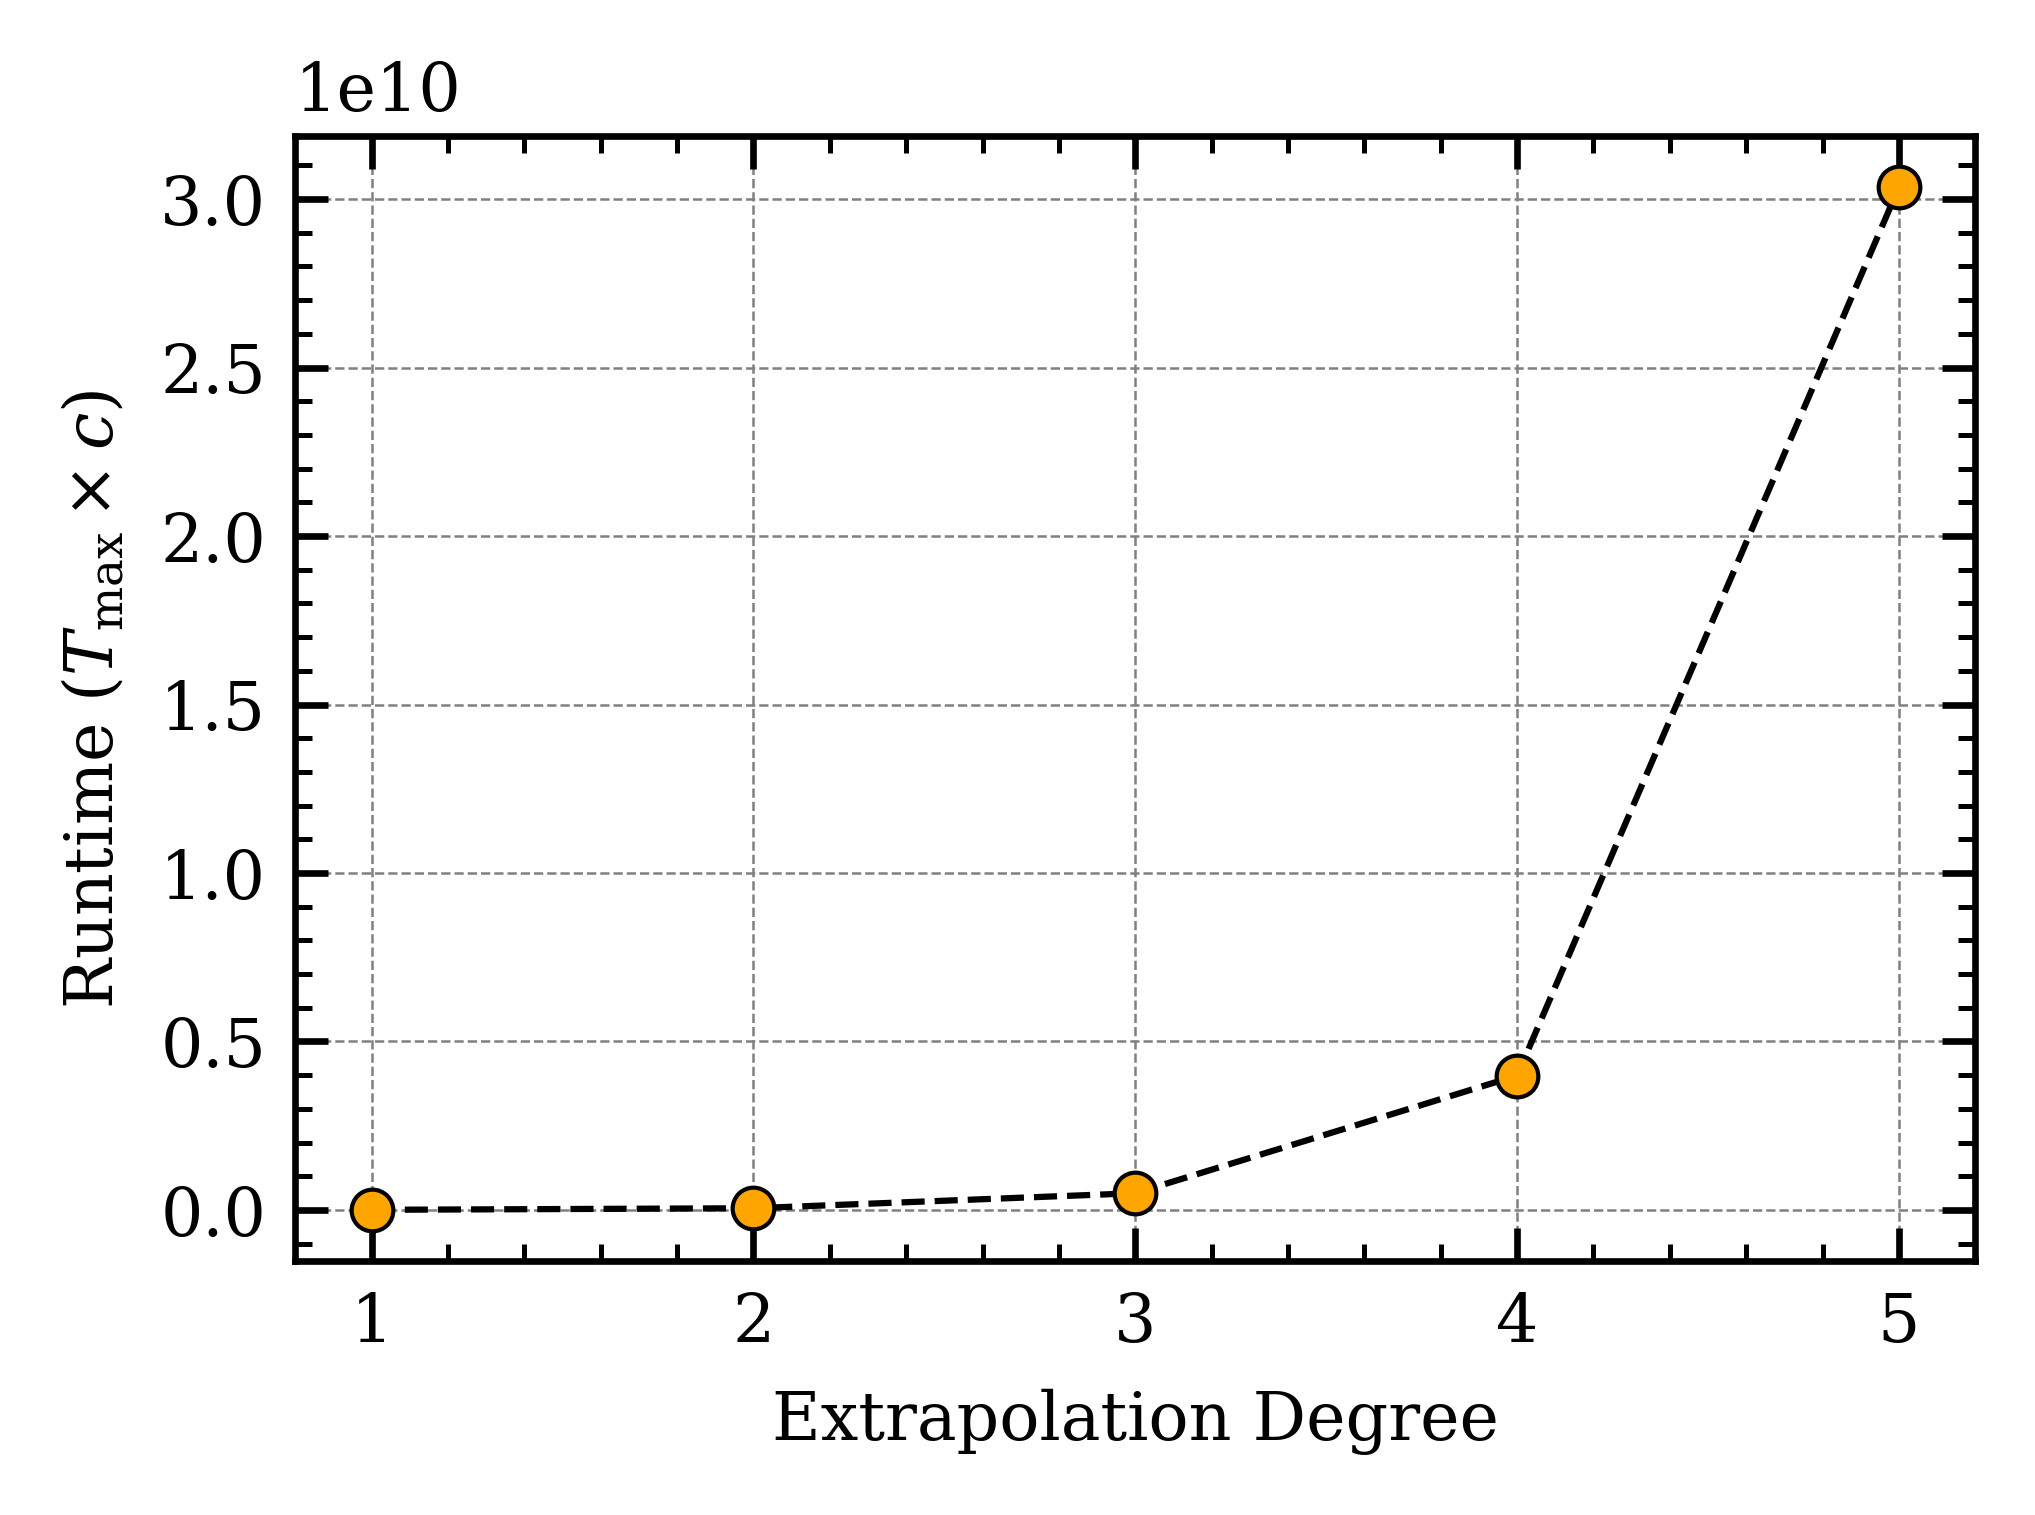

In [32]:
# Sort by degree
degree_list, runtime_list = zip(
    *sorted(zip(degree_list, runtime_list))
)

plt.figure(figsize=(3.5, 2.5))

plt.plot(
    degree_list,
    runtime_list,
    'o--',
    color='black',
    markerfacecolor='orange',
    markeredgecolor='black',
    markeredgewidth=0.5,
    linewidth=0.75,
    markersize=5,
)

#plt.yscale('log')  # optional, if runtime spans orders of magnitude

plt.xlabel('Extrapolation Degree', fontsize=8)
plt.ylabel(r'Runtime ($T_{\max} \times c$)', fontsize=8)

plt.grid(
    True,
    color='grey',
    linestyle='--',
    linewidth=0.3
)

plt.subplots_adjust(
    left=0.18,
    right=0.98,
    top=0.95,
    bottom=0.20
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        f"REVIEW--{_SYSTEM_HEISENEBRG}_runtime_vs_degree.eps"
    ),
    format="eps",
    dpi=600
)

plt.show()
plt.close()

In [33]:
cost_caliing_num :int = RAW_SIM_DATA["8Q-t20-dephasing-target-heisenberg"]["VQE"]["8Q-t20-dephasing-target-heisenberg_run000_VQE"]["others"]["cost_callings"]
final_T_max = RAW_SIM_DATA["8Q-t20-dephasing-target-heisenberg"]["VQE"]["8Q-t20-dephasing-target-heisenberg_run000_VQE"]["output"]["optimized_parameters"][0][29]
sum_eta_squared = RAW_SIM_DATA["8Q-t20-dephasing-target-heisenberg"]["ZNE"]["ZNE-mul-var"]["muld1"]["AUTOMATE_xy-iss_8Q-t20-dephasing-target-heisenberg_ricmul_d1_sample#1_20260621_093424_ZNE"]["output"]["zne_values"]["others"]["cost_zne"]
fixed_var :float = 0.01
N_shots_required = (8 * sum_eta_squared )/ fixed_var
print(f"Shots required: {N_shots_required}")
runtime = final_T_max * cost_caliing_num * N_shots_required
print(f"Runtime: {runtime}")

Shots required: 9800.0
Runtime: 3020590377.329674


## Mean-Squared Error in estimation

Refer to: 
[Cai, Z., Babbush, R., Benjamin, S., Endo, S., Huggins, W., Li, Y., McClean, J., & O’Brien, T. (2023). Quantum error mitigation. Reviews of Modern Physics, 95(4).](https://arxiv.org/abs/2210.00921)

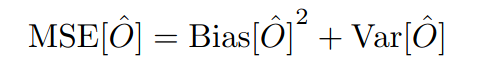

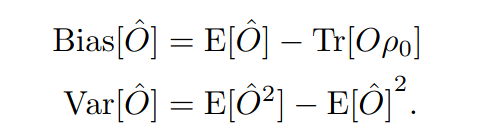

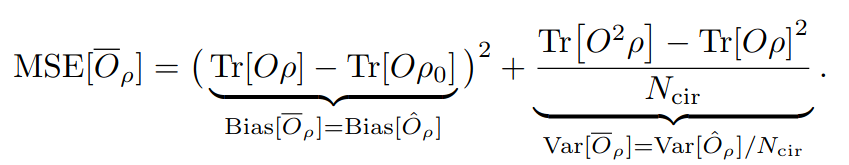

---

# Quantum Uncertaintity on Haar Random States

$Var(<H>) = [ (2N - 1) * D ] / [ D * (D + 1) ]
         = (2N - 1) / (D + 1)
         = (2N - 1) / (2^N + 1)$

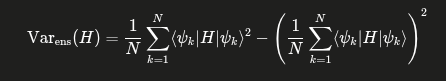


Quantum mechanical variance:

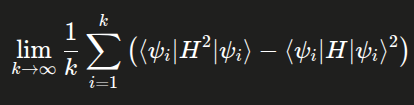

Number of shots:

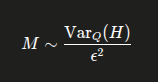

In [34]:
import numpy as np
from openfermion import QubitOperator
from qulacs import QuantumState
from qulacs.observable import create_observable_from_openfermion_text


def run_summed_variance_simulation(num_qubits, num_samples=500):
    # =========================================================================
    # STEP 1: Define all observables using OpenFermion
    # =========================================================================
    Hx = QubitOperator()
    Hz = QubitOperator()

    for i in range(num_qubits - 1):
        Hx += QubitOperator(f'X{i} X{i+1}', 1.0)

    for i in range(num_qubits):
        Hz += QubitOperator(f'Z{i}', 1.0)

    Hx_squared = Hx * Hx
    Hz_squared = Hz * Hz

    # =========================================================================
    # STEP 2: Convert OpenFermion operators to Qulacs observables
    # =========================================================================
    qulacs_Hx    = create_observable_from_openfermion_text(str(Hx))
    qulacs_Hz    = create_observable_from_openfermion_text(str(Hz))
    qulacs_Hx_sq = create_observable_from_openfermion_text(str(Hx_squared))
    qulacs_Hz_sq = create_observable_from_openfermion_text(str(Hz_squared))

    # =========================================================================
    # STEP 3: Collect expectations over the ensemble of Haar states
    # =========================================================================
    state = QuantumState(num_qubits)

    hx_exp,    hz_exp    = [], []
    hx_sq_exp, hz_sq_exp = [], []

    # Per-state TRUE quantum variance: Var_Q = <H²> - <H>²
    quantum_var_hx, quantum_var_hz = [], []

    for _ in range(num_samples):
        state.set_Haar_random_state()

        hx    = qulacs_Hx.get_expectation_value(state).real
        hx_sq = qulacs_Hx_sq.get_expectation_value(state).real
        hz    = qulacs_Hz.get_expectation_value(state).real
        hz_sq = qulacs_Hz_sq.get_expectation_value(state).real

        hx_exp.append(hx);       hz_exp.append(hz)
        hx_sq_exp.append(hx_sq); hz_sq_exp.append(hz_sq)

        # True quantum mechanical variance for this specific state
        quantum_var_hx.append(hx_sq - hx ** 2)
        quantum_var_hz.append(hz_sq - hz ** 2)

    hx_exp    = np.array(hx_exp);    hz_exp    = np.array(hz_exp)
    hx_sq_exp = np.array(hx_sq_exp); hz_sq_exp = np.array(hz_sq_exp)

    # =========================================================================
    # STEP 4a: FIXED ensemble variance  —  Var(X) = E[X²] - E[X]²
    #          measures how much <H> fluctuates across Haar-random states
    # =========================================================================
    ensemble_var_hx = np.mean(hx_exp ** 2) - np.mean(hx_exp) ** 2
    ensemble_var_hz = np.mean(hz_exp ** 2) - np.mean(hz_exp) ** 2

    # =========================================================================
    # STEP 4b: TRUE quantum variance  —  averaged over the Haar ensemble
    #          Var_Q(H)|ψ = <ψ|H²|ψ> - <ψ|H|ψ>²,  then averaged over ψ
    # =========================================================================
    mean_quantum_var_hx = np.mean(quantum_var_hx)
    mean_quantum_var_hz = np.mean(quantum_var_hz)

    return {
        # Ensemble (classical) variance of the expectation value
        "ensemble_var_hx": ensemble_var_hx,
        "ensemble_var_hz": ensemble_var_hz,
        "ensemble_var_total": ensemble_var_hx + ensemble_var_hz,

        # True quantum mechanical variance, averaged over Haar states
        "quantum_var_hx": mean_quantum_var_hx,
        "quantum_var_hz": mean_quantum_var_hz,
        "quantum_var_total": mean_quantum_var_hx + mean_quantum_var_hz,
    }


# --- Execution ---
num_qubits  = 8
num_samples = 20_000_0

results = run_summed_variance_simulation(num_qubits, num_samples)

print(f"=== Variance Analysis over {num_samples} Haar Samples ({num_qubits} Qubits) ===\n")

print("[ Ensemble variance  —  classical fluctuation of <ψ|H|ψ> across different Haar states ]")
print(f"  Formula : (1/N) Σ <ψk|H|ψk>²  -  ( (1/N) Σ <ψk|H|ψk> )²")
print(f"  Var_ens(Hx) : {results['ensemble_var_hx']:.6f}")
print(f"  Var_ens(Hz) : {results['ensemble_var_hz']:.6f}")
print(f"  Total       : {results['ensemble_var_total']:.6f}\n")

print("[ Quantum variance  —  spread of measurement outcomes inside one fixed state |ψ> ]")
print(f"  Formula : <ψk|H²|ψk>  -  <ψk|H|ψk>²  ,  then averaged over k")
print(f"  Var_QM(Hx) : {results['quantum_var_hx']:.6f}")
print(f"  Var_QM(Hz) : {results['quantum_var_hz']:.6f}")
print(f"  Total      : {results['quantum_var_total']:.6f}\n")

print("[ Relationship ]")
print(f"  Var_ens = (1/d) * Var_QM   where d = 2^n = {2**num_qubits}")
print(f"  Ratio Var_QM / Var_ens  (Hx): {results['quantum_var_hx'] / results['ensemble_var_hx']:.1f}  (expect {2**num_qubits})")
print(f"  Ratio Var_QM / Var_ens  (Hz): {results['quantum_var_hz'] / results['ensemble_var_hz']:.1f}  (expect {2**num_qubits})")

=== Variance Analysis over 200000 Haar Samples (8 Qubits) ===

[ Ensemble variance  —  classical fluctuation of <ψ|H|ψ> across different Haar states ]
  Formula : (1/N) Σ <ψk|H|ψk>²  -  ( (1/N) Σ <ψk|H|ψk> )²
  Var_ens(Hx) : 0.027171
  Var_ens(Hz) : 0.031174
  Total       : 0.058345

[ Quantum variance  —  spread of measurement outcomes inside one fixed state |ψ> ]
  Formula : <ψk|H²|ψk>  -  <ψk|H|ψk>²  ,  then averaged over k
  Var_QM(Hx) : 6.975193
  Var_QM(Hz) : 7.969912
  Total      : 14.945105

[ Relationship ]
  Var_ens = (1/d) * Var_QM   where d = 2^n = 256
  Ratio Var_QM / Var_ens  (Hx): 256.7  (expect 256)
  Ratio Var_QM / Var_ens  (Hz): 255.7  (expect 256)


In [35]:
# --- Execution ---
num_qubits  =10
num_samples = 20_00

results = run_summed_variance_simulation(num_qubits, num_samples)

print(f"=== Variance Analysis over {num_samples} Haar Samples ({num_qubits} Qubits) ===\n")

print("[ Ensemble variance  —  classical fluctuation of <ψ|H|ψ> across different Haar states ]")
print(f"  Formula : (1/N) Σ <ψk|H|ψk>²  -  ( (1/N) Σ <ψk|H|ψk> )²")
print(f"  Var_ens(Hx) : {results['ensemble_var_hx']:.6f}")
print(f"  Var_ens(Hz) : {results['ensemble_var_hz']:.6f}")
print(f"  Total       : {results['ensemble_var_total']:.6f}\n")

print("[ Quantum variance  —  spread of measurement outcomes inside one fixed state |ψ> ]")
print(f"  Formula : <ψk|H²|ψk>  -  <ψk|H|ψk>²  ,  then averaged over k")
print(f"  Var_QM(Hx) : {results['quantum_var_hx']:.6f}")
print(f"  Var_QM(Hz) : {results['quantum_var_hz']:.6f}")
print(f"  Total      : {results['quantum_var_total']:.6f}\n")

print("[ Relationship ]")
print(f"  Var_ens = (1/d) * Var_QM   where d = 2^n = {2**num_qubits}")
print(f"  Ratio Var_QM / Var_ens  (Hx): {results['quantum_var_hx'] / results['ensemble_var_hx']:.1f}  (expect {2**num_qubits})")
print(f"  Ratio Var_QM / Var_ens  (Hz): {results['quantum_var_hz'] / results['ensemble_var_hz']:.1f}  (expect {2**num_qubits})")

=== Variance Analysis over 2000 Haar Samples (10 Qubits) ===

[ Ensemble variance  —  classical fluctuation of <ψ|H|ψ> across different Haar states ]
  Formula : (1/N) Σ <ψk|H|ψk>²  -  ( (1/N) Σ <ψk|H|ψk> )²
  Var_ens(Hx) : 0.008329
  Var_ens(Hz) : 0.010262
  Total       : 0.018592

[ Quantum variance  —  spread of measurement outcomes inside one fixed state |ψ> ]
  Formula : <ψk|H²|ψk>  -  <ψk|H|ψk>²  ,  then averaged over k
  Var_QM(Hx) : 9.016754
  Var_QM(Hz) : 9.980224
  Total      : 18.996978

[ Relationship ]
  Var_ens = (1/d) * Var_QM   where d = 2^n = 1024
  Ratio Var_QM / Var_ens  (Hx): 1082.5  (expect 1024)
  Ratio Var_QM / Var_ens  (Hz): 972.5  (expect 1024)
